# Requirements

## Install necessary packages

In [2]:
"Install the necessary files"
!pip install arch
!pip install vectorbt
!pip install hmmlearn
!pip install dtw-python
"""
!pip install numpy
! pip install pandas
! pip install matplotlib
! pip install seaborn
!pip install scipy
!pip install scikit-learn
!pip install statsmodel
"""

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 985.3/985.3 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.8/527.8 kB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 315.5/315.5 kB 15.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 22.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 165.9/165.9 kB 3.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.1/48.1 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 801.7/801.7 kB 14.3 MB/s eta 0:00:00


'\n!pip install numpy\n! pip install pandas\n! pip install matplotlib\n! pip install seaborn\n!pip install scipy\n!pip install scikit-learn\n!pip install statsmodel\n'

## Import the necessary Packages

In [3]:
import math
import time
import numpy as np
import pandas as pd
import pickle
import copy
import os
import random
import bisect
from numba import njit, types,deferred_type
from numba.experimental import jitclass
import warnings
from collections import deque
warnings.filterwarnings('ignore')
#-----------Similarity Calculator-----------#
from scipy.stats import pearsonr
#----------------Volatility Modelling--------#
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from arch import arch_model
from hmmlearn import hmm
#---------------Plotting--------------------#
import matplotlib.pyplot as plt
import seaborn as sns
#---------------Backtest--------------------#
import vectorbt as vbt

#--------------Ablation Markers-------------#
from scipy.stats import ks_2samp


from google.colab import files
from dtw import dtw

Importing the dtw module. When using in academic works please cite:
  T. Giorgino. Computing and Visualizing Dynamic Time Warping Alignments in R: The dtw Package.
  J. Stat. Soft., doi:10.18637/jss.v031.i07.



In [4]:
import re
import os
# Add these imports at the top
from multiprocessing import Pool
import copy
from functools import partial

## Provide seed for reproducability

In [5]:
SEED = 119
random.seed(SEED)
np.random.seed(SEED)

# Create a global random state object
global_random_state = random.Random(SEED)
global_np_random_state=np.random.RandomState(SEED)

# Basic Tree Structure

In [5]:
class TreeNode:
  def __init__(self, val=0, height=1, ismut=False, left=None, right=None):
    '''
    Tree structure used for the genetic algorithm (GA).
    Internal nodes are operators, and leaves are base strategies.
    '''
    self.val = val
    self.left = left
    self.right = right
    self.height = height
    self.ismut = ismut

  def __repr__(self):
    return f"TreeNode({self.val})"

# Hyperparameters to be used

## Fixed Params

In [1]:
SEED = 55
random.seed(SEED)
np.random.seed(SEED)

# Create a global random state object
global_random_state = random.Random(SEED)
global_np_random_state=np.random.RandomState(SEED)
# Yang-Zhen window length considered to calculate true -volatility for a given day
yz_window = 30
# Parameters for conditional volatility
vol_params={'p':1,'q':1,'o':1,'power':2,'dist':"StudentsT"}
# Number of Technical Indicators/Strategies/Base Alphas we intend to use(remeber first 5 columns are OHCLV values)
num_indicators=30
# Number of operators to combine the indicators
num_bin_operators=4# when changing this change the Tree Signal function to use the operators you wish to keep
num_operators=6# when changing this change the Tree Signal function to use the operators you wish to keep
# Need to define the following values each for cross-over and mutation effectively
beta1,beta2,eta=0.85,0.93,1e-3
# Number of individuals you want to generate
num_individuals=150
num_elite=int(0.1*num_individuals)
# fraction of elite population you want to preserve
frac_elite=0.05
# Set the threshold for similarity
sim_threshold=0.8
# Rate limits for crossover
R_min_cross,R_max_cross=0.4,0.9
# Rate limits for mutation
R_min_mut,R_max_mut=0.1,0.3

# Backtest Params
asset_lab="SP500"
init_cash=10000 # the amount you begin with
sl_stop=0.05 # stop loss in percentage
tp_stop=0.03 # take profit in percentage
size_port=5 # the percentage of current portfolio value you want to place order
size_port_type='percent'
slippage=0.001
fees=0.001
freq='1D' # the type of dataset day,mins,hour...

# signal threshold beyond which the newly computed signal can be buy or sell
signal_threshold=1.0
ini_warm_fac=2
# integration params
num_generations=30
stopping_generation=6
stop_threshold=0.01
ini_prev_cross,ini_prev_cross_mom,ini_curr_cross,ini_prev_cross_vel=0.5,1e-3,0.6,1e-3
ini_prev_mut,ini_prev_mut_mom,ini_curr_mut,ini_prev_mut_vel=0.15,1e-3,0.2,1e-3
num_depth=3

#final execution params
#the indices for the training and and testing rolling window datasets along with the no. of days
#to shift the combined dataset for robust training and testing over the entire dataset
train_start,train_end,test_start,test_end,sliding_window=0,1000,1000,1500,150
fixed_train_len=train_end-train_start
fixed_test_len=test_end-test_start
#warmstart params
warmstart_percent=0.9#controlling this will control the consecutivewarmstarts
curr_warmstart_percent=warmstart_percent
num_regimes,vanilla_window=2,100#no.of regimes we want to classify into
dataset_iteration=0#denotes the sub-dataset being used
#avg_sharpe_dict:the avg of top 10% of the strategies for each dataset,avg_test_res:avg of the best strategy for each depth
avg_sharpe_dict,avg_test_res={},{}
#Get the depthwise relevant information in form of dictionary
dict_low,dict_high,dataset_iteration={},{},0
for d in range(2,num_depth+1):
  avg_sharpe_dict[d]=[]
  avg_test_res[d]=0.0
start_col=5
warmstart_tree_high=[TreeNode(i) for i in range(num_indicators)]
warmstart_tree_low=[TreeNode(i) for i in range(num_indicators)]

NameError: name 'random' is not defined

## Ablation Params

In [ ]:
#Hyperparameters for ablation:
#If we want to do simulated annealing
is_simulated=False
#change in the population of the best individual
exp_del_p={}#storing the population of the best individual
price_del_p={}#the one calculated using price and particle filter

#If we want to do consecutive datasets warmstart
is_consecutive_warmstart=True
trac_tree_dic_high,trac_tree_dic_low={},{}
tracker_high,tracker_low={},{}
if(not is_consecutive_warmstart):
  warmstart_percent=0.0
  curr_warmstart_percent=warmstart_percent

#If we want to do fixed rates for crossover and mutation
is_fixed_rate=True#False:Adaptive rates will be used ,True:You are using fixed rates for crossover/mutation
fixed_cross_rate=1e-8
fixed_mut_rate=1e-8

#Initialize the above hyperparameters
for d in range(2,num_depth+1):
  avg_sharpe_dict[d]=[]
  avg_test_res[d]=0.0
  trac_tree_dic_high[d]=[]
  trac_tree_dic_low[d]=[]
  tracker_high[d]=[]
  tracker_low[d]=[]
  exp_del_p[d]={}
  price_del_p[d]={}
print(warmstart_percent,curr_warmstart_percent)

## Simulated Annealing Ablation


In [ ]:
# This function is correct as you wrote it.
def simulated_cdf(fitness_arr):
    """
    Calculates the Empirical CDF for each individual.
    Input: A list of tuples, e.g., [(fitness_val, original_index), ...]
    """
    # Sort by fitness value
    sorted_fit_arr = sorted(fitness_arr, key=lambda x: x[0])
    total_individuals = len(fitness_arr)
    cdf_arr = np.zeros(total_individuals)*1.0
    # Assign CDF value based on rank
    for rank, (fit, original_index) in enumerate(sorted_fit_arr):
        cdf_arr[int(original_index)] = (rank + 1) / total_individuals

    return cdf_arr

# Corrected version.
def get_best_niche_info(org_fitness_arr):
    """
    Finds the proportion (p) and index of the best niche.
    """
    sorted_fit_arr = sorted(org_fitness_arr, key=lambda x: x[0],reverse=True)
    for rank in range(1,len(sorted_fit_arr)):
      if(sorted_fit_arr[rank][0]<sorted_fit_arr[0][0]):
        return rank/len(sorted_fit_arr),sorted_fit_arr[rank-1][1]
    return 1.0,len(sorted_fit_arr)-1

# Corrected version.
def predict_delta_p(org_fitness_arr, modified_fitness_arr, tournament_size=3):
    """
    Calculates the theoretically predicted change in population, Δp.
    """
    # 0. Get the proportion (p) and index of the best niche from RAW fitness
    p, best_idx = get_best_niche_info(org_fitness_arr)
    N=len(org_fitness_arr)
    if p == 1.0: # If the niche has taken over, there can be no more change
        return 0.0

    # 2. Calculate the ECDF of the MODIFIED fitness landscape
    cdf_values = simulated_cdf(modified_fitness_arr)

    # 3. Calculate the reproductive success (w) for every individual
    # This is where we include the tournament size
    w_values = (tournament_size/N**(tournament_size-1)) * (cdf_values ** (tournament_size - 1))

    # 4. Get the w for the best niche and the average w
    w_best = w_values[best_idx]
    w_bar = np.mean(w_values)

    if w_bar == 0: # Avoid division by zero
        return 0.0

    # 5. Calculate Δp using the corrected Price/Replicator equation form
    delta_p = p * (w_best - w_bar) / w_bar
    return delta_p

# Dataset Preprocessing

In [9]:
#Load the dataset-comment this for Local Loading
from google.colab import files
file=files.upload()

Saving zscored_indicators_spy.csv to zscored_indicators_spy.csv


In [12]:
# The first 5 columns of you're dataset must be C,H,L,O,V
file_path = "zscored_indicators_spy.csv"# replace with the filename you want to use
df = pd.read_csv(file_path)

In [13]:
# Define OHLCV columns as a set for efficient lookup
cols_to_shift = df.columns[start_col:len(df.columns)]
df[cols_to_shift] = df[cols_to_shift].shift(1)
df.loc[0, cols_to_shift] = 0
df.fillna(0, inplace=True)
ohlcv_cols_set = {'Open', 'High', 'Low', 'Close', 'Volume', 'Date'}
feature_cols = [col for col in df.columns if col not in ohlcv_cols_set]
random.shuffle(feature_cols)
# This maps original shuffled names to f1, f2, ...
rename_map = {old_name: f'f{idx+1}' for idx, old_name in enumerate(feature_cols)}
print(rename_map)
# Rename the columns in the DataFrame
df.rename(columns=rename_map, inplace=True)

# --- Reordering the DataFrame ---
ohlcv_cols_list = ['Date', 'Open', 'High', 'Low', 'Close', 'Volume']

# Extract all 'f' columns and sort them numerically
f_cols = sorted([col for col in df.columns if re.match(r'^f\d+$', col)],
                key=lambda x: int(x[1:]))
final_col_order = ohlcv_cols_list + f_cols
df = df[final_col_order]
df.head()

{'BOP': 'f1', 'MACD_12_26': 'f2', 'TSF_81': 'f3', 'MINUS_DI_17': 'f4', 'ROC_24': 'f5', 'RSI_13': 'f6', 'TRIX_7': 'f7', 'PPO_21_23': 'f8', 'CORREL_105': 'f9', 'ADX_75': 'f10', 'OBV_SLOPE_113': 'f11', 'BETA_123': 'f12', 'RSI_12': 'f13', 'ATR_99': 'f14', 'ADOSC_48_71': 'f15', 'CDLRICKSHAWMAN': 'f16', 'CCI_45': 'f17', 'STDDEV_136': 'f18', 'PLUS_DI_15': 'f19', 'MACD_20_75': 'f20', 'ATR_18': 'f21', 'ADOSC_27_73': 'f22', 'AD': 'f23', 'MOM_48': 'f24', 'STOCH2_K': 'f25', 'ROC_118': 'f26', 'CCI_98': 'f27', 'STOCHRSI_45': 'f28', 'MOM_123': 'f29', 'ULTOSC_2': 'f30', 'NATR_78': 'f31', 'STOCHRSI_140': 'f32', 'ADX_35': 'f33', 'CMO_13': 'f34', 'SLOPE_63': 'f35', 'PPO_12_14': 'f36', 'PLUS_DI_141': 'f37', 'STOCH1_K': 'f38', 'OBV_SLOPE_22': 'f39', 'CORREL_8': 'f40', 'CDLHARAMI': 'f41', 'CMO_10': 'f42', 'CDLHIKKAKE': 'f43', 'TRANGE': 'f44', 'ULTOSC_1': 'f45', 'NATR_11': 'f46', 'BETA_48': 'f47', 'STDDEV_11': 'f48', 'MINUS_DI_130': 'f49', 'CDL3OUTSIDE': 'f50', 'SLOPE_123': 'f51', 'TSF_107': 'f52', 'TRIX_140

,Date,Open,High,Low,Close,Volume,f1,f2,f3,f4,...,f44,f45,f46,f47,f48,f49,f50,f51,f52,f53
0,2004-08-02 04:00:00+00:00,1101.719971,1108.599976,1097.339966,1106.619995,0.000000e+00,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
1,2004-08-03 04:00:00+00:00,1106.619995,1106.619995,1099.260010,1099.689941,1.276000e+09,0.687726,-0.766716,0.291685,-1.213052,...,-0.136889,1.055094,-0.437716,-0.172521,-0.775280,0.542831,0.0,-1.246024,0.511115,-2.018548
2,2004-08-04 04:00:00+00:00,1099.689941,1102.449951,1092.400024,1098.630005,1.338300e+09,-1.627352,-0.687118,-0.017820,-1.385831,...,-0.973367,1.132143,-0.635056,-0.164570,-0.781618,0.413327,0.0,-1.238086,0.227180,-2.011157
3,2004-08-05 04:00:00+00:00,1098.630005,1098.790039,1079.979980,1080.699951,1.369200e+09,-0.236565,-0.629820,-0.076312,-0.689627,...,-0.363434,1.366739,-0.665022,0.150697,-1.010096,0.740916,0.0,-1.220417,0.176114,-2.004145
4,2004-08-06 04:00:00+00:00,1080.699951,1080.699951,1062.229980,1063.969971,1.397400e+09,-1.644353,-0.827961,-0.851099,0.429698,...,1.573865,0.034145,0.015916,0.221030,-0.618441,1.319582,0.0,-1.218156,-0.527258,-1.998008


In [14]:
#Preprocessing for warmstart based training data
#creating the dataframe
def test_signal_generator(optim_tree,base_signals):
    final_signal=np.array([tree_signal(base_signals,optim_tree)][0])
    # Apply thresholding to classify signals
    final_signal = np.where(final_signal >signal_threshold, 1, np.where(final_signal < -signal_threshold, -1, 0))
    return final_signal


def dataset_preprocess(df,indicator_cols,start_idx,end_idx,isfirst=False,istest=False):
    if istest:
       base_signals = df[indicator_cols].values.T
       return base_signals
    base_signals=(df[indicator_cols][start_idx:end_idx].values.T)
    if isfirst:
        base_trees = [TreeNode(i) for i in range(len(indicator_cols))]
        return base_trees,base_signals
    return base_signals

In [ ]:
"""
{'BOP': 'f1', 'MACD_12_26': 'f2', 'TSF_81': 'f3', 'MINUS_DI_17': 'f4', 'ROC_24': 'f5', 'RSI_13': 'f6', 'TRIX_7': 'f7', 'PPO_21_23': 'f8', 'CORREL_105': 'f9', 'ADX_75': 'f10', 'OBV_SLOPE_113': 'f11', 'BETA_123': 'f12', 'RSI_12': 'f13', 'ATR_99': 'f14', 'ADOSC_48_71': 'f15', 'CDLRICKSHAWMAN': 'f16', 'CCI_45': 'f17', 'STDDEV_136': 'f18', 'PLUS_DI_15': 'f19', 'MACD_20_75': 'f20', 'ATR_18': 'f21', 'ADOSC_27_73': 'f22', 'AD': 'f23', 'MOM_48': 'f24', 'STOCH2_K': 'f25', 'ROC_118': 'f26', 'CCI_98': 'f27', 'STOCHRSI_45': 'f28', 'MOM_123': 'f29', 'ULTOSC_2': 'f30', 'NATR_78': 'f31', 'STOCHRSI_140': 'f32', 'ADX_35': 'f33', 'CMO_13': 'f34', 'SLOPE_63': 'f35', 'PPO_12_14': 'f36', 'PLUS_DI_141': 'f37', 'STOCH1_K': 'f38', 'OBV_SLOPE_22': 'f39', 'CORREL_8': 'f40', 'CDLHARAMI': 'f41', 'CMO_10': 'f42', 'CDLHIKKAKE': 'f43', 'TRANGE': 'f44', 'ULTOSC_1': 'f45', 'NATR_11': 'f46', 'BETA_48': 'f47', 'STDDEV_11': 'f48', 'MINUS_DI_130': 'f49', 'CDL3OUTSIDE': 'f50', 'SLOPE_123': 'f51', 'TSF_107': 'f52', 'TRIX_140': 'f53'}

"""

# Volatility Modelling

## Yang-Zhen Modelling

In [24]:
def calc_true_volatility(df,yz_window=30):
    """
    This method is used to model the true-historical volatility.
    We use the Yang-Zhen Model for this purpose.
    """
    # Ensure numeric types
    for col in ['Open', 'High', 'Low', 'Close']:
        df[col] = pd.to_numeric(df[col], errors='coerce')

    # Drop rows where any OHLC is missing
    df = df.dropna(subset=['Open', 'High', 'Low', 'Close']).reset_index(drop=True)

    # Extract OHLC
    open_prices = df['Open']
    high_prices = df['High']
    low_prices = df['Low']
    close_prices = df['Close']

    # Calculate returns
    r_cc = np.log(close_prices / close_prices.shift(1)).dropna()  # Close-to-Close
    r_oc = np.log(open_prices / close_prices.shift(1)).dropna()   # Open-to-Previous-Close
    r_s = (np.log(high_prices / open_prices) * np.log(high_prices / close_prices) +
           np.log(low_prices / open_prices) * np.log(low_prices / close_prices)).dropna()  # Rogers-Satchell

    # Align lengths: they are now Series, so make them arrays
    r_cc = r_cc.to_numpy()
    r_oc = r_oc.to_numpy()
    r_s = r_s.to_numpy()

    d = len(r_cc)  # after shift, 1 less than df
    k = 0.34 / (1.34 + ((yz_window + 1) / (yz_window - 1)))


    # Preallocate
    yz_vol = np.full(d, np.nan)

    # Rolling calculation
    for i in range(yz_window, d):
        sigma_c = np.std(r_cc[i - yz_window:i], ddof=1)
        sigma_o = np.std(r_oc[i - yz_window:i], ddof=1)
        sigma_rs = np.mean(r_s[i - yz_window:i])
        yz_vol[i] = np.sqrt(k * sigma_o**2 + (1 - k) * sigma_c**2 + sigma_rs)
    for i in range(yz_window):
        sigma_c = np.std(r_cc[:i], ddof=1) if i > 0 else 1e-8
        sigma_o = np.std(r_oc[:i], ddof=1) if i > 0 else 1e-8
        sigma_rs = np.mean(r_s[:i])
        if(np.isnan(sigma_c)):
            sigma_c=1e-8
        if(np.isnan(sigma_o)):
            sigma_o=1e-8
        if(np.isnan(sigma_rs)):
            sigma_rs=1e-8
        yz_vol[i] = np.sqrt(k * sigma_o**2 + (1 - k) * sigma_c**2 + sigma_rs)

    return yz_vol
historical_volatility=calc_true_volatility(df,yz_window=yz_window)

## Conditional Volatility Model Selection

In [25]:
def volatility_selector(df,method='bootstrap'):
  """
  This method is used to select the volatility model that will be employed
  over the entire dataset.We use the bootstrap method to forecast and the vol_params
  defined earlier to train the model.In order to experiment with different models we can
  change the params defined above.Based on that we select the model with lower AIC/BIC
  scores and RMSE value over test dataset.
  """
  returns=df['Close'].pct_change().dropna()
  returns=(returns*100)
  train_end=0.85*len(returns)
  train_returns=np.array(returns[:int(train_end)])
  test_returns=np.array(returns[int(train_end):])
  volatility_model=arch_model(train_returns,p=vol_params['p'],
                            q=vol_params['q'],
                            o=(vol_params['o'] if vol_params['o']!=-1 else 0),
                            power=(vol_params['power'] if vol_params['power']!=-1 else 2),
                            dist=(vol_params['dist'] if 'dist' in vol_params.keys() else "normal"))
  volatility_model_fit=volatility_model.fit(disp='off')
  #print(volatility_model_fit.summary())
  train_volatility=volatility_model_fit.conditional_volatility
  test_volatility=volatility_model_fit.forecast(horizon=len(test_returns),method=method).variance.values[-1]
  train_historical_volatility=historical_volatility[:int(train_end)]
  test_historical_volatility=historical_volatility[int(train_end):]
  f1=(np.max(train_volatility)-np.min(train_volatility))/(np.max(train_historical_volatility)-np.min(train_historical_volatility))
  f2=(np.max(test_volatility)-np.min(test_volatility))/(np.max(test_historical_volatility)-np.min(test_historical_volatility))
  train_volatility=train_volatility*(1/f1)
  test_volatility=test_volatility*(1/f2)
  # Compute RMSE
  rmse = np.sqrt(np.mean((test_historical_volatility-test_volatility) ** 2))
  #print("RMSE:", rmse)
  return rmse

## Volatility Classifier

In [26]:
def volatility_classifier(dataset):
  #Calculate the corresponding percentwise returns
  log_returns = dataset.pct_change().dropna()
  log_returns = np.abs(log_returns*100)

  # Fit the GARCH model
  model = arch_model(log_returns,
                     p=vol_params['p'],
                     q=vol_params['q'],
                     o=vol_params['o'],
                     power=vol_params['power'],
                     dist=vol_params['dist'])
  garch_result = model.fit(disp="off")
  predict_vol = garch_result.conditional_volatility#for train
  window = vanilla_window
  block_volatility=[np.mean(predict_vol[i:(i+window)])for i in range(0,len(predict_vol),window)]

  #Finally classify as High or Low
  vol_mean=np.mean(block_volatility)
  block_volatility=np.array([int(r>(vol_mean)) for r in block_volatility])

  #Now classify the data into high and low volatility regions and indexes
  start_high_ind,end_high_ind,start_low_ind,end_low_ind=[],[],[],[]
  high_vol_dataset,low_vol_dataset=[],[]
  #Get the datasets for different regions
  curr=dataset.iloc[:window,:]
  start_ind,end_ind=0,window
  for i,vol in enumerate(block_volatility):
    if(not i):
      continue
    if(vol!=block_volatility[i-1]):
      if(vol==1):
        start_low_ind.append(start_ind)
        end_low_ind.append(end_ind)
        low_vol_dataset.append(curr)
      else:
        start_high_ind.append(start_ind)
        end_high_ind.append(end_ind)
        high_vol_dataset.append(curr)
      start_ind=end_ind
      curr=dataset.iloc[(i-1)*window:i*window,:]
    else:
      curr=pd.concat([curr,dataset.iloc[(i-1)*window:i*window,:]])
    end_ind+=window
  if(block_volatility[-1]==1):
    start_high_ind.append(start_ind)
    end_high_ind.append(end_ind)
    high_vol_dataset.append(curr)
  else:
    start_low_ind.append(start_ind)
    end_low_ind.append(end_ind)
    low_vol_dataset.append(curr)
  return garch_result,predict_vol,high_vol_dataset,low_vol_dataset,start_high_ind,end_high_ind,start_low_ind,end_low_ind

def volatility_classifier_hmm(dataset):
  pass

# Tree Structure

## Tree Definition

In [21]:
def tree_signal(base_signals, node):
    """
    Recursively evaluates a signal tree using base signals and operators.

    Args:
        base_signals (list of np.array): Base strategy signals.
        node (TreeNode): Root of the expression tree.

    Returns:
        np.array: Final signal with dtype np.int8.
    """
    if node is None:
        return np.zeros(len(base_signals[0]), dtype=np.float16)

    # Leaf node
    if node.left is None and node.right is None:
        return base_signals[node.val].astype(np.float16)
    result = np.zeros(len(base_signals[0]), dtype=np.float16)
    # Evaluate left and/or right children as needed
    if node.val in {5,6,7,8,9,10}:  # Unary operators
        child_signal = tree_signal(base_signals, node.left).astype(np.float16)

        if node.val == 5:  # abs
            result = np.abs(child_signal)
        elif node.val == 6:  # cos
            result = np.cos(child_signal)
        elif node.val == 7: # sin
            result = np.sin(child_signal)
        elif node.val == 8:  # tan
            result = np.tan(child_signal)
        elif node.val == 9:  # exp
            result = np.exp(child_signal)
        elif node.val == 10:  # log (safe)
            safe_signal = np.where(child_signal > 0, child_signal, 1e-6)
            result = np.log(safe_signal)

    else:  # Binary operators
        left = tree_signal(base_signals, node.left).astype(np.float16)
        right = tree_signal(base_signals, node.right).astype(np.float16)

        if node.val == 0:  # sum
            result = left + right
        elif node.val == 1:  # subtract
            result = left - right
        elif node.val == 2:  # multiply
            result = left * right
        elif node.val == 3:  # max
            result = np.maximum(left, right)
        elif node.val == 4:  # min
            result = np.minimum(left, right)
        """
        elif node.val == 5:  # protected division
            result = np.where(right != 0, left / right,1)
        """

    return result.astype(np.float16)


## Tree Utils

In [22]:
def get_height(root):
  """
  This function is to get the height of the tree.
  Args:
      root (TreeNode): The root node of the tree.
  Returns:
      int: The height of the tree.
  """
  if root is None:
    return 0
  return 1 + max(get_height(root.left), get_height(root.right))


def bfs(root, depth,random_state=global_random_state):
  """
  This function performs a breadth-first search (BFS) to
  find a node at a given depth.(used in crossover/mutation)
  Args:
      root (TreeNode): The root node of the tree.
      depth (int): The depth to search for.
  Returns:
      TreeNode: The node at the given depth, or None if not found.
  """
  if random_state is None:
        random_state = random  # Use global random if no local random_state is provided
  if depth == 0 or not root:
    return root

  queue = deque([root])

  for _ in range(depth):  # Iterate through levels
    if not queue:  # If we run out of nodes, return None
      return None
    for _ in range(len(queue)):  # Process each level
      node = queue.popleft()
      if node.left:
        queue.append(node.left)
      if node.right:
        queue.append(node.right)

  return random_state.choice(queue) if queue else None


def unary_create_tree(tree,op_node,val):
    """
    This function increases the depth of the tree using binary operator
    Args:
        tree(TreeNode) : The strategy tree
        op_node(TreeNode): The unary operator to add on the tree
        val(int): The value of the op_node
    Returns:
        TreeNode :The new tree after addition of unary operator
    """
    op_node.val = val
    op_node.left = tree
    op_node.height = get_height(op_node)
    return op_node

def binary_create_tree(tree1,tree2,op_node,val):
    """
    This function increases the depth of the tree using unary operator
    Args:
        tree1(TreeNode) : The first strategy tree
        tree2(TreeNode) : The second strategy tree
        op_node(TreeNode): The binary operator to add on the tree
        val(int): The value of the op_node
    Returns:
        TreeNode :The new tree after addition of binary operator
    """
    op_node.val = val
    op_node.left = tree1
    op_node.right = tree2
    op_node.height = get_height(op_node)
    return op_node

def add_depth_binary(base_pop,n,random_state=global_random_state):
    """
    This function increases the depth of the tree using binary operator
    for the list of input strategies array
    Args:
        base_pop(List[TreeNode]) : Array of strategy trees
        n(int):No of binary  trees to be created
    Returns:
        List[TreeNode] :The new tree(strategy) population after combining
                        them with binary operator
    """
    if random_state is None:
        random_state = random  # Use global random if no local random_state is provided

    count = len(base_pop)
    total_pairs = (int)(0.5*count*(count-1))
    chosen_indices = random_state.sample(range(1,total_pairs),n-1)
    base_pop_new = []

    # prefSum
    s,ps,c= 0,[],count-1
    while c > 0:
      s+=c
      ps.append(s)
      c-=1

    for i in chosen_indices:
        left_id = bisect.bisect_right(ps, i)
        rr = i - ps[max(left_id-1,0)]
        right_id = left_id + rr
        root = TreeNode()
        root = binary_create_tree(base_pop[left_id], base_pop[right_id], root,global_np_random_state.randint(0,num_bin_operators))
        base_pop_new.append(root)

    return base_pop_new

def add_depth_unary(base_pop,n,random_state=global_random_state):
  """
  This function increases the depth of the tree using unary operator
  for the list of input strategies array
  Args:
      base_pop(List[TreeNode]) : Array of strategy trees
      n(int):No of unary  trees to be created
  Returns:
      List[TreeNode] :The new tree(strategy) population after combining
                      them with unary operator
  """
  if random_state is None:
        random_state = random  # Use global random if no local random_state is provided

  chosen_indices = random_state.sample(range(0,len(base_pop)),n)
  base_pop_new = []
  for i in chosen_indices:
        root = TreeNode()
        root = unary_create_tree(base_pop[i], root,global_np_random_state.randint(num_bin_operators,num_operators))
        base_pop_new.append(root)
  return base_pop_new

## Similarity Structure of Trees

In [23]:
def check_same(tree1, tree2):
    if tree1 is None and tree2 is None:
        return True
    if tree1 is None or tree2 is None:
        return False
    if tree1.val != tree2.val:
        return False

    # Check for commutative operators
    if tree1.val in [0,2,3,4]:  # Assuming 0 = +, 2 = *,3=max,4=min
        return ((check_same(tree1.left, tree2.left) and check_same(tree1.right, tree2.right)) or
                (check_same(tree1.left, tree2.right) and check_same(tree1.right, tree2.left)))

    # All other operators are compared normally
    return check_same(tree1.left, tree2.left) and check_same(tree1.right, tree2.right)


# Backtest Function

In [27]:
class BuyAndHoldBacktest:
    def __init__(self, dataset):
        # Ensure the dataset has the necessary columns
        if 'Close' not in dataset.columns:
            raise ValueError("Dataset must contain a 'Close' column.")

        self.df = dataset.copy()
        asset_label = asset_lab

        # Create entry and exit signals
        entries = pd.Series(False, index=self.df.index)
        exits = pd.Series(False, index=self.df.index)
        entries.iloc[0] = True  # Enter on the first day
        exits.iloc[-1] = True   # Exit on the last day

        # Create a portfolio with the buy-and-hold strategy
        self.portfolio = vbt.Portfolio.from_signals(
            close=self.df['Close'],
            entries=entries,
            exits=exits,
            init_cash=init_cash,
            fees=fees,
            slippage=slippage,
            freq=freq
        )

    def get_portfolio(self):
        return self.portfolio


In [28]:
class SingleVectorBacktest:
    def __init__(self,dataset,terminal_signal):
        """
        Perform backtesting on a single trading signal vector.

        Args:
            dataset (pd.DataFrame): DataFrame with at least a 'Close' column.
            terminal_signal (pd.Series or np.array): 1D array of signals (1=buy, -1=sell, 0=hold).
            asset_lab (str): The label for the asset being traded.
            ... other vectorbt parameters
        """
        self.df = dataset.copy()

        # Shift the signal by 1 to prevent lookahead bias.
        shifted_signal = pd.Series(terminal_signal, index=self.df.index).shift(1).fillna(0)

        # Set the last position to -1 (exit) for all strategies
        shifted_signal.iloc[-1] = -1

        entries = shifted_signal == 1
        exits = shifted_signal == -1

        # vectorbt expects prices in a column named after the asset
        price = self.df['Close']

        self.portfolio = vbt.Portfolio.from_signals(
            price,
            entries,
            exits,
            init_cash=init_cash,
            sl_stop=sl_stop,
            tp_stop=tp_stop,
            size=size_port,
            size_type=size_port_type,
            slippage=slippage,
            fees=fees,
            accumulate=True,
            freq=freq
        )

    def port_ret(self):
        # Return the portfolio object.
        return self.portfolio

    def fitness(self, type="information_ratio"):
        # Calculate benchmark returns (Buy and Hold) directly from the price data
        benchmark_rets = self.df['Close'].vbt.to_returns()
        metrics = self.port_ret()

        if type == "sharpe":
            return metrics.sharpe_ratio()
        elif type == "information_ratio":
            return 100 * metrics.information_ratio(benchmark_rets=benchmark_rets)
        elif type == "max_drawdown":
            # max_drawdown is negative, so we negate it to make it a positive value to maximize
            return -metrics.max_drawdown()
        elif type == "calmar_ratio":
            return metrics.calmar_ratio()
        elif type == "sortino_ratio":
            return metrics.sortino_ratio()
        elif type == "omega_ratio":
            return metrics.omega_ratio()
        else:
            pass




In [29]:
class VectorBacktest:
  def __init__(self,dataset,terminal_signals,fusion=False):
    """
    Perform backtesting on trading strategies using decision trees for signal generation.
    The backtest is conducted using the VectorBT library for portfolio simulation.

    Attributes:
        strategy_tree (TreeNode): The decision tree representing the strategy.
        dataset (pd.DataFrame): Historical price data for backtesting.
        terminal_signals (list[list[int]]): Predefined base signals for each time point.
        fusion (bool): Whether to apply Kalman smoothing to the generated signals.
    """
    self.df = dataset.copy()
    self.test_signal = np.array(terminal_signals)
    assert self.test_signal.shape[1] == len(self.df), "Signals must match dataset length"
    shifted_signals = np.roll(self.test_signal, shift=1, axis=1)

    #Set the last position to -1 (exit) for all strategies
    shifted_signals[:, -1] = -1
    shifted_signals[:,0] = 0
    signal_df = pd.DataFrame(
            shifted_signals.T,
            index=self.df.index,
            columns=[f'sig{i+1}' for i in range(self.test_signal.shape[0])]
        )
    entries_df = signal_df == 1
    exits_df   = signal_df == -1
    asset_label = asset_lab
    entries = entries_df.vbt.stack_index(pd.Index([asset_label] * entries_df.shape[1], name="asset"))
    exits   = exits_df.vbt.stack_index(pd.Index([asset_label] * exits_df.shape[1], name="asset"))

    price_df = self.df[['Close']].copy()
    price_df.columns = [asset_label]
    price_df.columns.name = 'asset'

    self.portfolio = vbt.Portfolio.from_signals(
            price_df,
            entries,
            exits,
            init_cash=init_cash,
            sl_stop=sl_stop,
            tp_stop=tp_stop,
            size=size_port,
            size_type=size_port_type,
            slippage=slippage,
            fees=fees,
            accumulate=True,
            freq=freq
        )
  def port_ret(self):
        # Return the portfolio object.
        return self.portfolio
  def fitness(self,type="sharpe"):
      backtest=BuyAndHoldBacktest(self.df[['Close']].copy())
      metrics=self.port_ret()
      if(type=="sharpe"):
        return metrics.sharpe_ratio()
      elif(type=="information_ratio"):
        return 100*metrics.information_ratio(benchmark_rets=backtest.get_portfolio().returns())
      elif(type=="max_drawdown"):
        return -metrics.max_drawdown()
      elif(type=="calmar_ratio"):
        return metrics.calmar_ratio()
      elif(type=="sortino_ratio"):
        return metrics.sortino_ratio()
      elif(type=="omega_ratio"):
        return metrics.omega_ratio()
      else:#here I encourage to try out combined fitness functions
        pass

# Genetic Programming Architecture

## Crossover

In [30]:

def unary_rootswap(root_a, root_b):
  """
  Function to swap subtree when the root node of one
  subtree is a unary operator and the other is binary.
  Args:
    root_a: Unary operator rooted subtree
    root_b:Binary operator rooted subtree
  """
  if root_a.left and root_b.left:
    left_subtree= root_a.left
    r = global_np_random_state.randint(0, 2)
    if r:
      root_a.left, root_b.right = root_b.right, left_subtree
    else:
      root_a.left, root_b.left = root_b.left, left_subtree


def binary_rootswap(node_a, node_b):
  """
  Function to swap subtree when the root node of both
  subtrees are binary operators.
  Args:
    node_a: Binary operator rooted subtree
    node_b:Binary operator rooted subtree
  """
  node_a.val, node_b.val = node_b.val, node_a.val  # Swap values
  #Swap left subtree
  node_a.left, node_b.left = node_b.left, node_a.left

  #Swap right subtree
  node_a.right, node_b.right = node_b.right, node_a.right


#This is the crossover between 2 buy or 2 sell signals at any random node at a particular depth d.
def crossover(tree1, tree2):
  """
  Perform crossover between two strategy trees at random depths.
  Args:
    tree1 (TreeNode): First strategy tree.
    tree2 (TreeNode): Second strategy tree.

  Returns:
     tuple: Two child trees resulting from the crossover.
  """
  height1 = get_height(tree1)
  height2 = get_height(tree2)
  if (height1<= 1 or height2<=1):
    return copy.deepcopy(tree1), copy.deepcopy(tree2)  # Return copies if tree too shallow

  depth1 = global_np_random_state.randint(0, height1 - 1)  # range = [0, h-2]
  depth2 = global_np_random_state.randint(0, height2 - 1)

  child1, child2 = copy.deepcopy(tree1), copy.deepcopy(tree2)
  root1, root2 = bfs(child1, depth1), bfs(child2, depth2)

  if root1 and root2:
    # If both nodes are unary operators
    if root1.val >= num_bin_operators and root2.val >= num_bin_operators:
      root1.left, root2.left = root2.left, root1.left

    # If only one is 'abs'; apply unary swap
    elif root1.val >= num_bin_operators:
      unary_rootswap(root1, root2)
    elif root2.val >= num_bin_operators:
      unary_rootswap(root2, root1)

    # Otherwise, perform standard binary swap
    else:
      swap_choice = global_random_state.choice(['left_left', 'right_right', 'left_right', 'right_left'])
      if swap_choice == 'left_left' and root1.left and root2.left:
        binary_rootswap(root1.left, root2.left)
      elif swap_choice == 'left_right' and root1.left and root2.right:
        binary_rootswap(root1.left, root2.right)
      elif swap_choice == 'right_left' and root1.right and root2.left:
        binary_rootswap(root1.right, root2.left)
      elif swap_choice == 'right_right' and root1.right and root2.right:
        binary_rootswap(root1.right, root2.right)

  return child1, child2

## Mutation & Selection

In [31]:

def mutation(root,num_base=num_indicators):
  """
  Perform (point)mutation on a strategy tree by modifying a random node's value.
  Args:
    root (TreeNode): Root of the strategy tree to mutate.
    num_base(int) : Number of base signals
  Returns:
    The tree is modified in-place.
  """
  if root is None:
    return root  # Handle edge case where tree is empty

  tree_height = get_height(root)
  random_depth = global_np_random_state.randint(0, tree_height)  # Pick a random depth
  node = bfs(root, random_depth)  # Get a random node at that depth
  node_height = get_height(node)  # Get the height of the node
  if node is None:
    return root  # No valid node found, return tree unchanged

  def set_value(beg,end):
    new_val = global_np_random_state.randint(beg,end)
    while new_val == node.val:  # Ensure mutation actually changes the value
      new_val = global_np_random_state.randint(beg,end)
    node.val = new_val
  if node_height == 1:  # If it's a leaf node
    set_value(0,num_base)

  else:  # If it's an internal node
    if node.val >= num_bin_operators:  # If it's a NOT operator (assuming 5 represents NOT)
      set_value(num_bin_operators,num_operators)
    else:
      set_value(0,num_bin_operators)
  return root

# tournament selection to determine the parents
def tournament_selection(fitness_arr, k = 3):
    """
    Perform tournament selection to choose a parent based on fitness.
    Args:
        fitness_arr (list): List of fitness scores for individuals.
        k (int, optional): Number of individuals to select for the tournament (default: 3).
    Returns:
        int: Index of the selected individual.
    """
    tournament = global_random_state.sample(list(enumerate(fitness_arr)), k)
    winner = max(tournament, key=lambda x: float(x[1][0]))
    id = winner[1][1]
    return id

## Adaptive Rate(ADAM Based)

In [32]:


def _calculate_elite_mean_fitness(fitness_array, elite_perc=10.0):
    """Calculates the mean fitness of the top elite_perc percent of individuals."""
    if not fitness_array:
        return 0.0  # Handle empty list case

    # Ensure fitness values are floats
    try:
        fit_values = np.array([t[0] if isinstance(t, tuple) else t for t in fitness_array], dtype=float)
        # Handles potential NaNs or Infs introduced
        fit_values = fit_values[np.isfinite(fit_values)]
        if fit_values.size == 0:
            return 0.0
    except (TypeError, ValueError) as e:
        warnings.warn(f"Could not process fitness array: {fitness_array}. Error: {e}. Returning 0.0")
        return 0.0

    population_size = len(fit_values)
    if population_size == 0:
        return 0.0

    # Ensure elite_perc is within [0, 100]
    elite_perc = max(0.0, min(100.0, elite_perc))
    if elite_perc == 0.0:
        return 0.0

    # Calculates number of elite individuals (at least 1 if population > 0 and perc > 0)
    num_elite = max(1, int(np.floor(population_size * elite_perc / 100.0)))
    num_elite = min(num_elite, population_size) # Cannot exceed population size

    sorted_fitness = np.sort(fit_values)[::-1] # Sort descending
    top_elite_fitness = sorted_fitness[:num_elite]

    return np.mean(top_elite_fitness)


def adam_rate_controller(
    prev_rate: float,
    curr_rate: float,
    prev_momentum: float,
    prev_velocity: float,
    prev_fitness_arr: list,
    curr_fitness_arr: list,
    beta1: float,
    beta2:float,
    eta: float,
    rate_bounds: tuple[float, float],
    curr_gen=1,
    epsilon: float = 1e-8,
    grad_clip_range: tuple[float, float] | None = (-1e6, 1e6),
    elite_perc: float = 10.0,
    add_noise: bool = True,
    noise_scale: float = 0.005,
    random_state: np.random.RandomState | None = None
) -> tuple[float, float,float]:
    """
    Dynamically adjusts a GA operator rate (mutation/crossover) based on fitness gradients
    using momentum.

    Args:
        prev_rate (float): Operator rate used in the previous generation.
        curr_rate (float): Operator rate used in the current generation.
        prev_momentum (float): Momentum value from the previous generation.
        prev_velocity (float): Velocity value from the previous generation.
        prev_fitness_arr (list): Fitness values from the previous generation's population.
        curr_fitness_arr (list): Fitness values from the current generation's population.
        beta1 (float): Momentum factor (e.g., 0.9). Controls smoothing.
        beta2 (float): Momentum factor for velocity (e.g., 0.999).
        eta (float): Learning rate for rate adjustment.(0.001)
        rate_bounds (tuple[float, float]): Min and Max allowed values for the rate (e.g., (0.5, 0.8)).
        curr_gen (int): Current generation number.
        epsilon (float, optional): Small value to prevent division by zero in gradient denominator. Defaults to 1e-8.
        grad_clip_range (tuple[float, float] | None, optional): Min/Max values to clip the raw gradient to.
            Set to None to disable gradient clipping. Defaults to (-10.0, 10.0).
        elite_perc (float, optional): Percentage of top individuals to consider for fitness change. Defaults to 10.0.
        add_noise (bool, optional): Whether to add small uniform noise to the updated rate. Defaults to True.
        noise_scale (float, optional): The amplitude of the uniform noise (+/- this value). Defaults to 0.005.
        random_state (np.random.RandomState | None, optional): NumPy random state generator for reproducible noise.
            If None, uses np.random. Defaults to None.

    Returns:
        tuple[float, float]: (next_rate, current_momentum) - The calculated rate for the *next* generation
                             and the momentum value calculated in *this* generation.
    """

    # --- 1. Calculate change in elite fitness ---
    prev_top_mean = _calculate_elite_mean_fitness(prev_fitness_arr, elite_perc)
    curr_top_mean = _calculate_elite_mean_fitness(curr_fitness_arr, elite_perc)
    delta_fitness = (curr_top_mean - prev_top_mean)#*100
    print(f"The change in fitness is {delta_fitness}")
    # --- 2. Calculate robust change in rate ---
    delta_rate_raw = curr_rate - prev_rate
    # Use sign * max(abs(delta), epsilon) to prevent division by zero/small numbers while preserving the direction of change.
    delta_rate_clipped = np.sign(delta_rate_raw) * max(abs(delta_rate_raw), epsilon)

    # --- 3. Estimate Gradient ---
    # Gradient = change_in_fitness / change_in_rate.This estimates the sensitivity of elite fitness to changes in the operator rate.
    if delta_rate_clipped == 0:
         # This case should ideally not be reached due to the epsilon floor, but handle defensively.
         avg_grad = 0.0
         warnings.warn("Delta rate was zero even after epsilon flooring.")
    else:
        avg_grad = delta_fitness / delta_rate_clipped

    # --- 4. Clip Gradient (Optional) ---
    # Clipping prevents extreme gradient values (often due to noise or tiny denominators) from causing excessively large swings in momentum and rate updates.
    if grad_clip_range is not None:
        avg_grad = np.clip(avg_grad, grad_clip_range[0], grad_clip_range[1])

    # --- 5. Update Momentum ---
    # Smooths the gradient signal over time.
    curr_momentum = beta1 * prev_momentum + (1 - beta1) * avg_grad
    curr_velocity = beta2 * prev_velocity + (1 - beta2) * avg_grad**2
    curr_momentum = curr_momentum / (1 - beta1**curr_gen)
    curr_velocity = curr_velocity / (1 - beta2**curr_gen)

    # --- 6. Update Rate ---
    # Adjust the *current* rate based on the momentum signal to get the *next* rate.Using '+' assumes positive momentum (indicating rate increase was beneficial)should lead to a further rate increase.
    next_rate = curr_rate + eta * (curr_momentum/(curr_velocity**0.5+epsilon))

    # --- 8. Clip Rate to Bounds ---
    R_min, R_max = rate_bounds
    next_rate = np.clip(next_rate, R_min, R_max)

    return next_rate,curr_momentum,curr_velocity

## Similarity Scores of Strategies

In [33]:
def calculate_similarity_matrix_np(data_matrix):
    """
    Calculates the Pearson similarity (correlation) matrix for a 2D NumPy array.

    Assumes rows are variables (e.g., PnL arrays) and columns are observations (e.g., time points).

    Args:
        data_matrix: A 2D NumPy array where each row is a data series (e.g., shape (num_individual, num_days)).

    Returns:
        A 2D NumPy array representing the pairwise Pearson correlation matrix
        (e.g., shape (num_individual,num_individual)). Returns NaN for correlations involving
        constant rows (zero standard deviation) or rows with insufficient data points.
    """
    # --- Input Validation---
    if not isinstance(data_matrix, np.ndarray):
        raise TypeError("Input must be a NumPy array.")
    if data_matrix.ndim != 2:
        raise ValueError(f"Input must be a 2D array, but got {data_matrix.ndim} dimensions.")

    num_arrays = data_matrix.shape[0]
    num_samples = data_matrix.shape[1]

    if num_arrays == 0:
        print("Warning: Input array has 0 rows. Returning empty matrix.")
        return np.array([]) # Return empty 2D array

    if num_arrays == 1:
        print("Warning: Input array has only 1 row. Correlation with itself is 1.")
        return np.array([[1.0]]) # Correlation of an array with itself

    if num_samples < 2:
        print(f"Warning: Number of samples ({num_samples}) is less than 2. Cannot calculate correlation.")
        return np.full((num_arrays, num_arrays), np.nan) # Return NaN matrix

    # --- Calculate Correlation Matrix ---
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=RuntimeWarning)
        # Ensure input is float for correlation calculation
        correlation_matrix = np.corrcoef(data_matrix.astype(float, copy=False))

    # Safeguard for unexpected scalar output (should be handled by checks above)
    if correlation_matrix.shape == ():
         return np.full((num_arrays, num_arrays), np.nan)

    # Ensure the output shape is correct
    if correlation_matrix.shape != (num_arrays, num_arrays):
         print(f"Warning: Unexpected output shape {correlation_matrix.shape}. Expected ({num_arrays}, {num_arrays}). Returning NaN matrix.")
         return np.full((num_arrays, num_arrays), np.nan)

    return correlation_matrix


def analyze_similarity(similarity_matrix, threshold=sim_threshold):
    """
    Analyzes a similarity matrix: replaces NaNs with 0 and counts items
    above a threshold for each row (excluding self-similarity).

    Args:
        similarity_matrix: The 2D NumPy array correlation matrix (potentially containing NaNs).
        threshold: The float correlation threshold for counting neighbors.

    Returns:
        A tuple containing:
        - cleaned_matrix: The similarity matrix with NaNs replaced by 0.
        - counts_above_threshold: A 1D NumPy array where counts_above_threshold[i]
                                  is the number of items j (j!=i) such that
                                  cleaned_matrix[i, j] > threshold.
    """
    if not isinstance(similarity_matrix, np.ndarray) or similarity_matrix.ndim != 2:
         raise ValueError("Input similarity_matrix must be a 2D NumPy array.")
    if similarity_matrix.shape[0] != similarity_matrix.shape[1]:
         raise ValueError("Input similarity_matrix must be square.")

    # 1. Replace NaNs with 0
    cleaned_matrix = np.nan_to_num(similarity_matrix, nan=0.0)

    # 2. Count elements above threshold (excluding diagonal)
    num_items = cleaned_matrix.shape[0]
    if num_items == 0:
        return cleaned_matrix, np.array([], dtype=int) # Return empty counts for empty input

    # Create boolean matrix where condition (value > threshold) is met
    above_threshold_matrix = cleaned_matrix > threshold

    # The diagonal is False to exclude self-similarity (corr(i, i)),so we only count j != i
    np.fill_diagonal(above_threshold_matrix, False)

    # Sum the True values along each row (axis=1) to get the count for each item
    counts_above_threshold = np.sum(above_threshold_matrix, axis=1, dtype=int)

    return cleaned_matrix, counts_above_threshold

## Next Generation Module

In [34]:
def fitness_suppresser(pnl_list, fitness_list, curr_gen, tot_gen):
    multiplicative_factor = np.exp(-(curr_gen)/tot_gen)
    pnl_list = np.array(pnl_list)
    initial_similarity_matrix = calculate_similarity_matrix_np(pnl_list)
    _, counts = analyze_similarity(initial_similarity_matrix)

    # Create a new list to store updated fitness values
    updated_fitness_list = []

    for idx, (fit_val, index) in enumerate(fitness_list):
        cnt = counts[index]
        if (((1.0 + cnt) * multiplicative_factor)>1):
            fit_val = fit_val #/ ((1.0 + cnt) * multiplicative_factor)
        updated_fitness_list.append((fit_val, index))

    return updated_fitness_list

def tree_fitness_calc(dataset, base_signals, tree_pop, return_port=False):
    tree_signal_arr = []
    for tree in tree_pop:
        final_signal = np.array([tree_signal(base_signals, tree)][0])
        # Apply thresholding to classify signals
        final_signal = np.where(final_signal >signal_threshold, 1, np.where(final_signal < -signal_threshold, -1, 0))
        tree_signal_arr.append(final_signal)

    tree_obj = VectorBacktest(dataset, tree_signal_arr)
    if return_port:
        return tree_obj, tree_obj.port_ret()

    tree_fitness = tree_obj.fitness()
    tree_fitness = [0 if (x > 200) else max(x,-200.0) for x in tree_fitness]
    return tree_fitness

def update_rates(curr_gen, prev_fitness, curr_fitness, update_mutation=True, **kwargs):
    if update_mutation:
        tag = "mut"
        R_min, R_max, curr_rate = R_min_mut, R_max_mut, kwargs["curr_mut_rate"]
    else:
        tag = "cross"
        R_min, R_max, curr_rate = R_min_cross, R_max_cross, kwargs["curr_cross_rate"]

    curr_ad, prev_mom, prev_vel = adam_rate_controller(
        kwargs[f"prev_{tag}_rate"],
        kwargs[f"curr_{tag}_rate"],
        kwargs[f"prev_{tag}_mom"],
        kwargs[f"prev_{tag}_vel"],
        prev_fitness,
        curr_fitness,
        beta1,
        beta2,
        eta,
        (R_min, R_max),
        curr_gen)

    kwargs[f"prev_{tag}_rate"] = curr_rate
    kwargs[f"curr_{tag}_rate"] = curr_ad
    kwargs[f"prev_{tag}_mom"] = prev_mom
    kwargs[f"prev_{tag}_vel"] = prev_vel

    return kwargs

def simulated_next_generation(base_signals,
                              tree_pop,
                              train_dataset,
                              curr_gen,
                              tot_gen,
                              fitness_arr,
                              depth,
                              ishigh,
                              **kwargs):
    """
    Evolve the next generation of strategies using simulated annealing based genetic algorithm.
    Args:
        base_signals: Base signals for the tree
        tree_pop: The current strategy tree population
        train_dataset: The dataset being used
        curr_gen: the current generation
        tot_gen: total no. of generations
        fitness_arr: The corresponding fitness of the tree population
        depth: Maximum tree depth
        **kwargs: Additional parameters including adaptive rates
    Returns:
        tree_pop_new: new strategy trees
        avg_new_fitness_pop: average fitness of the top 10 in new population
        fitness_new_arr: new fitness array for the corresponding strategies
        fitness_new_pnl_arr: new pnl array for the corresponding strategies
        **kwargs: updated parameters for adaptive rates
    """
    size = len(fitness_arr)
    if(is_fixed_rate):
      curr_cross_rate = fixed_cross_rate
      curr_mut_rate = fixed_mut_rate
    else:
      curr_cross_rate = kwargs["curr_cross_rate"]
      curr_mut_rate = kwargs["curr_mut_rate"]

    tree_pop_new = []

    # Preserve top performers (elitism)
    num_elite = int(len(fitness_arr) * frac_elite)

    # Calculating unadulterated fitness of previous population
    adam_prev_fitness = tree_fitness_calc(train_dataset, base_signals, tree_pop)
    old_par_fitness_arr=[x[0] for x in fitness_arr]
    print(f"the length of ablation previous array is {len(old_par_fitness_arr)}")
    sorted_fitness_arr = sorted(fitness_arr, key=lambda x: x[0], reverse=True)

    sel_par_fitness_mapper=[]
    for i in range(num_elite):
        id = sorted_fitness_arr[i][1]
        tree_pop_new.append(tree_pop[id])
        sel_par_fitness_mapper.append(fitness_arr[id][0])

    # Batching the population for faster inference
    child_tree_arr = []
    parent_tree_arr = []
    parent_tree_fitness_arr = []
    if np.isnan(curr_cross_rate):
        curr_cross_rate = R_max_cross

    # Create new individuals through crossover
    for i in range((size - num_elite) // 2):
        id1 = tournament_selection(fitness_arr)
        id2 = tournament_selection(fitness_arr)
        while id1 == id2:
            id2 = tournament_selection(fitness_arr)

        parent1 = tree_pop[id1]
        parent2 = tree_pop[id2]
        sel_par_fitness_mapper.append(fitness_arr[id1][0])
        sel_par_fitness_mapper.append(fitness_arr[id2][0])

        if random.random() < curr_cross_rate:
            # Perform crossover
            child1, child2 = crossover(parent1, parent2)

            child_tree_arr.append(child1)
            child_tree_arr.append(child2)
            parent_tree_arr.append(parent1)
            parent_tree_arr.append(parent2)
            parent_tree_fitness_arr.append(adam_prev_fitness[id1])
            parent_tree_fitness_arr.append(adam_prev_fitness[id2])
        else:
            tree_pop_new.append(parent1)
            tree_pop_new.append(parent2)

    # Evaluate children if there are any
    if child_tree_arr:
        child_sharpe = tree_fitness_calc(train_dataset, base_signals, child_tree_arr)

        for i in range(0, len(child_tree_arr), 2):
            if i+1 < len(child_tree_arr):
                if max(child_sharpe[i], child_sharpe[i+1]) > min(parent_tree_fitness_arr[i], parent_tree_fitness_arr[i+1]):
                    tree_pop_new.append(child_tree_arr[i])
                    tree_pop_new.append(child_tree_arr[i+1])
                else:
                    tree_pop_new.append(parent_tree_arr[i])
                    tree_pop_new.append(parent_tree_arr[i+1])

    # Mutate selected individuals
    if np.isnan(curr_mut_rate):
        curr_mut_rate = R_max_mut

    num_mut = int(len(tree_pop_new) * curr_mut_rate)
    if num_mut > 0:
        n_mut_arr = global_np_random_state.randint(0, len(tree_pop_new), size=num_mut)  # adaptive mutation
        for i in n_mut_arr:
            tree_pop_new[i] = mutation(tree_pop_new[i])

    # Evaluate new population fitness and penalize similarity
    fitness_new_arr, fitness_new_pnl_arr = [], []
    obj, metrics = tree_fitness_calc(train_dataset, base_signals, tree_pop_new, return_port=True)
    signal_names = metrics.value().columns

    for signal_name in signal_names:
        val = metrics.value()[signal_name].values
        fitness_new_pnl_arr.append(val)

    fitness_new_arr = [(0.0 if (x > 200 or x < -200) else x, ind) for ind, x in enumerate(obj.fitness())]
    adam_curr_fitness = [t[0] for t in fitness_new_arr]
    sorted_fit_gen_new = np.array([t[0] for t in sorted(fitness_new_arr, key=lambda x: x[0], reverse=True)])
    print(f"Current Generation population size and fitness score of elite population: {len(fitness_new_arr)}, {np.mean(sorted_fit_gen_new[:num_elite])}")

    if is_simulated:
        print("Started similarity assessment")
        org_fitness_arr=fitness_new_arr
        fitness_new_arr = fitness_suppresser(fitness_new_pnl_arr, fitness_new_arr, curr_gen, tot_gen)
        modified_fitness_arr=fitness_new_arr
    else:
        org_fitness_arr=fitness_new_arr
        modified_fitness_arr=fitness_new_arr

    price_val = predict_delta_p(org_fitness_arr, modified_fitness_arr)
    dataset_iteration = kwargs["dataset_iteration"]

    # Ensure the lists exist for the current dataset_iteration and depth
    if not ishigh:
      if dataset_iteration not in price_del_p[depth]:
          price_del_p[depth][dataset_iteration] = []
      if dataset_iteration not in exp_del_p[depth]:
          exp_del_p[depth][dataset_iteration] = []

      price_del_p[depth][dataset_iteration].append(price_val)
      exp_del_p[depth][dataset_iteration].append(get_best_niche_info(org_fitness_arr)[0])
    avg_new_fitness_pop = np.mean(sorted_fit_gen_new[:num_elite])

    # Update adaptive rates
    if is_fixed_rate==False:
      kwargs = update_rates(curr_gen, adam_prev_fitness, adam_curr_fitness, update_mutation=False, **kwargs)
      kwargs = update_rates(curr_gen, adam_prev_fitness, adam_curr_fitness, update_mutation=True, **kwargs)

    return tree_pop_new, avg_new_fitness_pop, fitness_new_arr, fitness_new_pnl_arr, kwargs

# Warmstart

## Version 1

In [35]:
def tree_creation_begin(base_pop):
    '''
    Generates the unary and binary rooted trees for the warmstart function
    '''
    count = len(base_pop)
    num_unary = global_np_random_state.randint(0,count)
    num_binary = int(num_individuals*ini_warm_fac)-num_unary
    binary_signals = add_depth_binary(base_pop,num_binary)
    unary_signals = add_depth_unary(base_pop,num_unary)

    return binary_signals + unary_signals

def warmstart_begin(trees):
    '''
    Performs warmstart and returns the first generation of alphas
    by generating a larger population size than required
    and randomly selects n individuals out of it
    '''
    warm_trees = tree_creation_begin(trees)
    random_population = global_random_state.sample(range(len(warm_trees)),num_individuals)
    fin_strategy_tree = [warm_trees[i] for i in random_population]
    return fin_strategy_tree


## Version 2

In [36]:
def tree_creation_advanced(multiplicative_factor,base_pop):
    ''''
    Generates the unary and binary rooted trees for the warmstart function
    Here we deliberately keep the number of unary population very less.
    '''
    count = int(num_individuals*multiplicative_factor)

    num_unary = global_np_random_state.randint(0,max(1,count//5))
    num_binary = count-num_unary
    num_unary=max(num_unary,0)
    num_binary=max(num_binary,0)
    print(f"Number of binary and unary trees and total count was : {num_binary},{num_unary}, {count}")
    if num_binary==0:
      return base_pop
    binary_signals = add_depth_binary(base_pop,num_binary)
    unary_signals = add_depth_unary(base_pop,num_unary)

    return binary_signals + unary_signals
def warmstart_advanced(prev_trees,trees,multiplicative_factor):#,prev_dict_trees):
    '''
    Performs warmstart and returns the generation of alphas for datasets
    other than the 1st one by generating a larger population size
    than required and randomly selecting n individuals out of it
    '''

    warm_trees= tree_creation_advanced(multiplicative_factor,trees)
    warm_trees=warm_trees+prev_trees
    if(num_individuals>len(warm_trees)):
        population_size=len(warm_trees)
    else:
      population_size=num_individuals
    random_population = global_random_state.sample(range(len(warm_trees)), population_size)
    fin_strategy_tree=[warm_trees[i] for i in random_population]
    return fin_strategy_tree

# Integration

## Version 1

In [39]:
def best_strategy(dataset,base_signals,prev_trees,depth,ishigh,**kwargs):

  """
  Finds the best strategy at a specific depth by initializing with a warm start and
  building higher generations iteratively.
  Args:
      dataset:the array of datasets
      base_signals: array of corresponding base signals
      base_trees: array of corresponding trees
      depth: the max depth
  Returns:
        best trees and their fitness for the given depth
  """
  warm_strategy_pop= warmstart_begin(prev_trees)

  if(ishigh):
    trac_tree_dic_high[depth]=warm_strategy_pop
    tracker_high[depth].append(len(warm_strategy_pop))
    print(f"For the first dataset with the high vol trees the size is {len(trac_tree_dic_high[depth])} for depth {depth}")
  else:
    trac_tree_dic_low[depth]=warm_strategy_pop
    tracker_low[depth].append(len(warm_strategy_pop))
    print(f"For the first dataset with the low vol trees the size is {len(trac_tree_dic_low[depth])} for depth {depth}")

  print("******************1st Warmstart Completed*********************************")
  strategy_optimal=warm_strategy_pop.copy()
  fitness_prev_arr, fitness_prev_pnl_arr = [], []
  best_fit, prev_fit,count= 0,0,1

  # Initial fitness evaluation
  tree_pop_new_fit_arr=[]
  for index,tree in enumerate(warm_strategy_pop):
    final_signal=np.array([tree_signal(base_signals[0],tree)][0])
    final_signal = np.where(final_signal >signal_threshold, 1, np.where(final_signal < -signal_threshold, -1, 0))
    tree_pop_new_fit_arr.append(final_signal)
  obj = VectorBacktest(dataset[0],tree_pop_new_fit_arr)
  metrics=obj.port_ret()
  fitness_prev_pnl_arr=[]
  for i,col in enumerate((metrics.value().columns)):
    val=(metrics.value()[col].values)
    fitness_prev_pnl_arr.append(val)
  fitness_prev_arr=[(0 if x > 200 else max(x,-200.0), ind) for ind,x in enumerate(obj.fitness())]
  """
  fitness_prev_arr_copy = fitness_prev_arr.copy()
  fitness_prev_pnl_arr=np.array(fitness_prev_pnl_arr)
  initial_similarity_matrix = calculate_similarity_matrix_np(fitness_prev_pnl_arr)
  cleaned_similarity_matrix, counts = analyze_similarity(initial_similarity_matrix)
  # Penalize similar chromosomes for diversity
  for fit_val, index in fitness_prev_arr:
    count = counts[index]
    fitness_prev_arr_copy[index] = (fit_val / (1.0 + count), index)
  fitness_prev_arr = fitness_prev_arr_copy
  """
  #Average fitness of top 10% strategies
  prev_fit = np.mean([t[0] for t in sorted(fitness_prev_arr, key=lambda x: x[0], reverse = True)[:num_elite]])

  #Distributed Evolution loop
  tot_dataset_len=sum([len(d) for d in dataset])
  generation_arr=[(num_generations*len(d))//(tot_dataset_len)+1 for d in dataset]

  if not kwargs.get("prev_cross_rate"):
    kwargs["prev_cross_rate"]=ini_prev_cross
    kwargs["curr_cross_rate"]=ini_curr_cross
    kwargs["prev_cross_mom"]=ini_prev_cross_mom
    kwargs["prev_cross_vel"]=ini_prev_cross_vel
    kwargs["prev_mut_rate"]=ini_prev_mut
    kwargs["curr_mut_rate"]=ini_curr_mut
    kwargs["prev_mut_mom"]=ini_prev_mut_mom
    kwargs["prev_mut_vel"]=ini_prev_mut_vel
    kwargs["beta1"]=beta1
    kwargs["beta2"]=beta2
    kwargs["eta"]=eta
    kwargs["dataset_iteration"]=0
  return strategy_optimal,prev_fit,kwargs
  tot_generations=0
  for j,dist_generation in enumerate(generation_arr):
    for gen in range(1,max(1,dist_generation)+1):
      print(f"########generation {tot_generations+gen} started################")
      warm_strategy_pop,next_gen_fit, fitness_prev_arr, fitness_prev_pnl_arr,kwargs = simulated_next_generation(base_signals[j],
                                                                                                                warm_strategy_pop,
                                                                                                                dataset[j],
                                                                                                                gen,
                                                                                                                dist_generation,
                                                                                                                fitness_prev_arr,
                                                                                                                depth,
                                                                                                                ishigh,
                                                                                                                **kwargs)
      #print(f"Current CrossOver {kwargs['prev_cross_rate']} , Current Mutation {kwargs['prev_mut_rate']}")
      if next_gen_fit > best_fit:
        best_fit, strategy_optimal= next_gen_fit,warm_strategy_pop.copy()

      # Early stopping if fitness improvement falls below threshold
      if abs(next_gen_fit - prev_fit) <=stop_threshold:
        count += 1
        if count>stopping_generation:
          break
      else:
        count = 1
      prev_fit = next_gen_fit
    tot_generations+=dist_generation
  return strategy_optimal,best_fit,kwargs



def integrator(dataset, base_signals,base_trees,ishigh,**kwargs):
  '''
  Integrates the optimization algorithm across multiple depths, building and optimizing
  strategies at each depth level.For each volatility regime we evolve the population through
  G generations dividing the number of generations into each dataset proportionate to their size.
  Args:
      dataset:the array of datasets
      base_signals: array of corresponding base signals
      base_trees: array of corresponding trees
      depth: the max depth
  Returns:
      The dictionary of depthwise strategy trees and their fitnesses
  '''
  if not base_trees or len(base_trees) == 0:
        raise ValueError("base_trees must contain at least one tree")
  strategy_optimal= base_trees[0]
  depth_dict= {}  # Stores results by addition of depth to the existing trees
  for d in range(2, num_depth + 1):
    strategy_optimal,best_fit,kwargs= best_strategy(dataset,base_signals,strategy_optimal,d,ishigh,**kwargs)
    depth_dict[d]={
        'best_fit': best_fit,
        'tree_opt':strategy_optimal,
        'prev_cross':kwargs["prev_cross_rate"],
        'prev_cross_mom':kwargs["prev_cross_mom"],
        'prev_cross_vel':kwargs["prev_cross_vel"],
        'curr_cross':kwargs["curr_cross_rate"],
        'prev_mut':kwargs["prev_mut_rate"],
        'prev_mut_mom':kwargs["prev_mut_mom"],
        'prev_mut_vel':kwargs["prev_mut_vel"],
        'curr_mut':kwargs["curr_mut_rate"],
        'dataset_iteration':kwargs["dataset_iteration"]
    }
    print(f"##*****************DEPTH {d} has BEST_FITNESS of {best_fit}***********************##")

  return depth_dict


## Version 2

In [40]:
def best_strategy_advanced(dataset,base_signals,prev_trees,
                           warmstart_percent,warmstart_tree,
                           best_fit,
                           depth,
                           ishigh,
                           **kwargs):
  """
  Finds the best strategy at a specific depth by initializing without a warm start and
  building higher generations iteratively.
  Args:
      dataset:the array of datasets
      base_signals: array of corresponding base signals
      base_trees: array of corresponding trees
      depth: the max depth
  Returns:
      Tbest trees and their fitness for the given depth
  """
  warm_strategy_pop= warmstart_advanced(prev_trees,warmstart_tree ,warmstart_percent)

  if(ishigh):
    dum_trac_tree_dic=[]
    for tree in trac_tree_dic_high[depth]:
      flag_present=False
      for new_tree in warm_strategy_pop:
        if check_same(tree,new_tree):
          flag_present=True
          break
      if flag_present:
        dum_trac_tree_dic.append(tree)
    tracker_high[depth].append(len(dum_trac_tree_dic))
  else:
    dum_trac_tree_dic=[]
    for tree in trac_tree_dic_low[depth]:
      flag_present=False
      for new_tree in warm_strategy_pop:
        if check_same(tree,new_tree):
          flag_present=True
          break
      if flag_present:
        dum_trac_tree_dic.append(tree)
    tracker_low[depth].append(len(dum_trac_tree_dic))

  print("******************Warmstart V2 Completed*********************************")
  fitness_prev_arr, fitness_prev_pnl_arr = [], []
  prev_fit, count= 0,1
  strategy_optimal= warm_strategy_pop#prev_trees
  # Initial fitness evaluation
  tree_pop_new_fit_arr=[]
  for index, tree in enumerate(warm_strategy_pop):
    final_signal=np.array([tree_signal(base_signals[0],tree)][0])
    final_signal = np.where(final_signal >signal_threshold, 1, np.where(final_signal < -signal_threshold, -1, 0))
    tree_pop_new_fit_arr.append(final_signal)
  obj = VectorBacktest(dataset[0],tree_pop_new_fit_arr)
  metrics=obj.port_ret()
  fitness_prev_pnl_arr=[]
  for i,col in enumerate((metrics.value().columns)):
    val=(metrics.value()[col].values)
    fitness_prev_pnl_arr.append(val)
  fitness_prev_arr=[(0 if x > 200 else max(x,-200.0), ind) for ind,x in enumerate(obj.fitness())]
  """
  fitness_prev_pnl_arr=np.array(fitness_prev_pnl_arr)
  initial_similarity_matrix = calculate_similarity_matrix_np(fitness_prev_pnl_arr)
  cleaned_similarity_matrix, counts = analyze_similarity(initial_similarity_matrix)
  # Penalize similar chromosomes for diversity
  for fit_val, index in fitness_prev_arr:
    cnt = counts[index]
    fitness_prev_arr[index] = (fit_val / (1.0 + cnt), index)
  """
  # Sort chromosomes by fitness(taking top 10)
  prev_fit = np.mean([t[0] for t in sorted(fitness_prev_arr, key=lambda x: x[0], reverse = True)[:num_elite]])
  return strategy_optimal,prev_fit,kwargs
  #Distributed Evolution loop
  tot_dataset_len=sum([len(d) for d in dataset])
  iter_arr=[(num_generations*len(d))//(tot_dataset_len)+1 for d in dataset]
  tot_it=0
  for j,dist_it in enumerate(iter_arr):
    dist_it=max(dist_it,2)
    for it in range(1,max(dist_it,1)+1):
      print(f"generation {tot_it+it} started!!")
      warm_strategy_pop,next_gen_fit, fitness_prev_arr, fitness_prev_pnl_arr,kwargs= simulated_next_generation(base_signals[j],
                                                                                                      warm_strategy_pop,dataset[j],
                                                                                                      it, dist_it, fitness_prev_arr,
                                                                                                      depth,ishigh,
                                                                                                      **kwargs)
      if next_gen_fit > best_fit:
        best_fit, strategy_optimal= next_gen_fit,warm_strategy_pop

      # Early stopping if fitness improvement falls below threshold
      if abs(next_gen_fit - prev_fit) <= stop_threshold:
        count += 1
        if count>stopping_generation:
          break
      else:
        count = 1
      prev_fit = next_gen_fit
    tot_it+=dist_it
  return strategy_optimal,best_fit,kwargs


def integrator_advanced(dataset, base_signals,new_trees,depth,
                        best_fit,warmstart_percent,warmstart_tree,ishigh,
                        **kwargs):
  """
  Integrates the optimization algorithm across multiple depths, building and optimizing
  strategies at each depth level.For each volatility regime we evolve the population through
  G generations dividing the number of generations into each dataset proportionate to their size.
  Args:
      dataset:the array of datasets
      base_signals: array of corresponding base signals
      base_trees: array of corresponding trees
      depth: the max depth
  Returns:
      The dictionary of depthwise strategy trees and their fitnesses
  """
  strategy_optimal= new_trees[0] # Stores results by depth
  strategy_optimal,best_fit,kwargs=best_strategy_advanced(dataset,base_signals,strategy_optimal,
                                                           warmstart_percent,warmstart_tree,best_fit,
                                                           depth,ishigh,#prev_dict_trees,
                                                           **kwargs)
  dicti={
        'best_fit': best_fit,
        'tree_opt': strategy_optimal,
        'prev_cross':kwargs["prev_cross_rate"],
        'prev_cross_mom':kwargs["prev_cross_mom"],
        'prev_cross_vel':kwargs["prev_cross_vel"],
        'curr_cross':kwargs["curr_cross_rate"],
        'prev_mut':kwargs["prev_mut_rate"],
        'prev_mut_mom':kwargs["prev_mut_mom"],
        'prev_mut_vel':kwargs["prev_mut_vel"],
        'curr_mut':kwargs["curr_mut_rate"],
        'dataset_iteration':kwargs["dataset_iteration"]
    }
  print(f"###################DEPTH {depth} has BEST_FITNESS of {best_fit}#######################")

  return dicti


# Final Execution

## Basic Exec

In [93]:
def oos_tester(train_start,train_end,oos_shift,oos_depth):
  train_df = df[train_start:train_end]
  train_dataset = pd.DataFrame(train_df[['Close']])
  garch_result,predict_vol,_,_,_,_,_,_=volatility_classifier(train_dataset)
  # Fit the GARCH model
  test_start,test_end=train_end,len(df)-oos_shift
  test_df=df[test_start:test_end]
  test_dataset = test_df[['Close']].copy()
  # Load the GARCH model and calculate predicted volatility
  pred_volatility = np.sqrt(garch_result.forecast(horizon=len(test_dataset), reindex=False).variance.values[-1])

  combined_vol=np.concatenate([predict_vol, pred_volatility])#predict_vol is for train
  print(fixed_train_len,len(combined_vol))
  for i in range(fixed_train_len,len(combined_vol)):
      roll_mean=np.mean(combined_vol[i-vanilla_window:i])
      pred_volatility[i-fixed_train_len]=np.where(pred_volatility[i-fixed_train_len]>roll_mean,1,0)
  base_signals=dataset_preprocess(test_df,list(df.columns[start_col:(start_col+num_indicators)]),0,0,istest=True)
  def out_of_sample_metrics(high_ind,low_ind):
    batch_signals=[]
    m1=time.time()
    high_optim_trees = dict_high[high_ind]["tree_opt"]
    low_optim_trees = dict_low[low_ind]["tree_opt"]
    high_final_signals,low_final_signals=[],[]
    test_signal_arr=[]
    for i in range(len(high_optim_trees)):
      high_final_signals.append(test_signal_generator(high_optim_trees[i],base_signals))
    for i in range(len(low_optim_trees)):
      low_final_signals.append(test_signal_generator(low_optim_trees[i],base_signals))
    for i in range(len(high_optim_trees)):
      for j in range(len(low_optim_trees)):
        #Combine signals based on predicted volatility
        testing_signal = np.where(pred_volatility, high_final_signals[i], low_final_signals[j])
        test_signal_arr.append(testing_signal)

    test_backtest_obj = VectorBacktest(test_dataset, test_signal_arr)
    elapsed = time.time() -m1
    print(f"Backtest complete in {elapsed:.3f} seconds\n")
    return test_backtest_obj.port_ret(),test_backtest_obj.port_ret().sharpe_ratio()
  metrics,fit_metric=out_of_sample_metrics(oos_depth,oos_depth)
  max_profit=-200
  av_sp=[]
  for i,prof in enumerate(fit_metric):
    if(prof<-200 or prof>200):
      continue
    av_sp.append(prof)
    if(prof>max_profit):
      max_profit=prof
  av_sp.sort(reverse=True)
  count_fin_strat=min(max(len(sorted_sharpe_ratio),1),int(0.01*(num_individuals**2)))
  avg_sharpe=np.mean(np.array(sorted_sharpe_ratio[:count_fin_strat]))
  return avg_sharpe

In [91]:
"""
Let's get into the main loop
"""
def shifter(train_start,train_end,test_start,test_end):
  train_start+=sliding_window
  train_end+=sliding_window
  test_start=train_end
  test_end+=sliding_window
  return train_start,train_end,test_start,test_end
while(test_end<(len(df))):
  #For each train-test pair dataset

  #Initializing the training dataset
  train_df=df[train_start:train_end]
  train_dataset = pd.DataFrame(train_df[['Close']])
  garch_result,predict_vol,high_vol_dataset,low_vol_dataset,start_high_ind,end_high_ind,start_low_ind,end_low_ind=volatility_classifier(train_dataset)
  """
  Now let's train on the current dataset:
  1.If it's the initial dataset then do warm-start and then do distributed evolution
  2.Do only distributed evolution with the previously evolved strategies
  """
  if(not dataset_iteration):
    #now get the base signals and the corresponding trees
    high_base_trees,high_base_signals=[],[]#for high vol regions
    low_base_trees,low_base_signals=[],[]#for low vol regions
    for i in range(len(start_high_ind)):
      high_base_trees1,high_base_signals1=dataset_preprocess(train_df,list(train_df.columns[start_col:(start_col+num_indicators)]),start_high_ind[i],end_high_ind[i],isfirst=True)
      high_base_trees.append(high_base_trees1)
      high_base_signals.append(high_base_signals1)
    for i in range(len(start_low_ind)):
      low_base_trees1,low_base_signals1=dataset_preprocess(train_df,list(train_df.columns[start_col:(start_col+num_indicators)]),start_low_ind[i],end_low_ind[i],isfirst=True)
      low_base_trees.append(low_base_trees1)
      low_base_signals.append(low_base_signals1)

    dict_low = integrator(low_vol_dataset,
                       low_base_signals,
                       low_base_trees,ishigh=False)
    dict_high = integrator(high_vol_dataset,
                       high_base_signals,
                       high_base_trees,ishigh=True)
  else:
    for index in range(2,num_depth+1):
      high_base_trees,high_base_signals=[],[]
      low_base_trees,low_base_signals=[],[]
      for i in range(len(start_high_ind)):
        high_base_signals1=dataset_preprocess(train_df,list(train_df.columns[start_col:(start_col+num_indicators)]),start_high_ind[i],end_high_ind[i])
        high_base_trees.append(dict_high[index]["tree_opt"])
        high_base_signals.append(high_base_signals1)

      for i in range(len(start_low_ind)):
        low_base_signals1=dataset_preprocess(train_df,list(train_df.columns[start_col:(start_col+num_indicators)]),start_low_ind[i],end_low_ind[i])
        low_base_trees.append(dict_low[index]["tree_opt"])
        low_base_signals.append(low_base_signals1)
      kwargs_low={}
      kwargs_low["beta1"]=beta1
      kwargs_low["beta2"]=beta2
      kwargs_low["eta"]=eta
      kwargs_low["dataset_iteration"]=dict_low[index]["dataset_iteration"]+1
      kwargs_low["prev_mut_vel"]=dict_low[index]["prev_mut_vel"]
      kwargs_low["prev_cross_rate"]=dict_low[index]["prev_cross"]
      kwargs_low["curr_cross_rate"]=dict_low[index]["curr_cross"]
      kwargs_low["prev_cross_mom"]=dict_low[index]["prev_cross_mom"]
      kwargs_low["prev_mut_rate"]=dict_low[index]["prev_mut"]
      kwargs_low["curr_mut_rate"]=dict_low[index]["curr_mut"]
      kwargs_low["prev_mut_mom"]=dict_low[index]["prev_mut_mom"]
      kwargs_low["prev_cross_vel"]=dict_low[index]["prev_cross_vel"]
      kwargs_high={}
      kwargs_high["beta1"]=beta1
      kwargs_high["beta2"]=beta2
      kwargs_high["eta"]=eta
      kwargs_high["prev_mut_vel"]=dict_high[index]["prev_mut_vel"]
      kwargs_high["prev_cross_rate"]=dict_high[index]["prev_cross"]
      kwargs_high["curr_cross_rate"]=dict_high[index]["curr_cross"]
      kwargs_high["prev_cross_mom"]=dict_high[index]["prev_cross_mom"]
      kwargs_high["prev_mut_rate"]=dict_high[index]["prev_mut"]
      kwargs_high["curr_mut_rate"]=dict_high[index]["curr_mut"]
      kwargs_high["prev_mut_mom"]=dict_high[index]["prev_mut_mom"]
      kwargs_high["prev_cross_vel"]=dict_high[index]["prev_cross_vel"]
      kwargs_high["dataset_iteration"]=dict_high[index]["dataset_iteration"]+1
      print(f"High vol dataset training started for next{dataset_iteration}")
      if(index>2):
        warmstart_tree_high=dict_high[index-1]["tree_opt"]
        warmstart_tree_low=dict_low[index-1]["tree_opt"]

      dict_high[index]=integrator_advanced(high_vol_dataset,
                            high_base_signals,
                            high_base_trees,index,dict_high[index]["best_fit"],
                              curr_warmstart_percent,warmstart_tree_high,
                              ishigh=True,**kwargs_high)
      print(f"Low vol dataset training started for next{dataset_iteration}")
      dict_low[index]=integrator_advanced(low_vol_dataset,
                            low_base_signals,
                            low_base_trees,index,dict_low[index]["best_fit"],
                            curr_warmstart_percent,warmstart_tree_low,
                            ishigh=False,**kwargs_low)
  curr_warmstart_percent*=warmstart_percent
  #Now let's test the tree based strategies
  print(f"Testing began for dataset {dataset_iteration}")
  test_df=df[test_start:test_end]
  test_dataset = test_df[['Close']].copy()
  # Load the GARCH model and calculate predicted volatility
  pred_volatility = np.sqrt(garch_result.forecast(horizon=len(test_dataset), reindex=False).variance.values[-1])
  combined_vol=np.concatenate([predict_vol, pred_volatility])#predict_vol is for train
  for i in range(fixed_train_len,len(combined_vol)):
    roll_mean=np.mean(combined_vol[i-vanilla_window:i])
    pred_volatility[i-fixed_train_len]=np.where(pred_volatility[i-fixed_train_len]>roll_mean,1,0)
  base_signals=dataset_preprocess(test_df,list(df.columns[start_col:(start_col+num_indicators)]),0,0,istest=True)

  for index in range(2,num_depth+1):
    high_optim_trees = dict_high[index]["tree_opt"]
    low_optim_trees = dict_low[index]["tree_opt"]
    high_final_signals,low_final_signals=[],[]
    test_signal_arr=[]
    for i in range(len(high_optim_trees)):
      high_final_signals.append(test_signal_generator(high_optim_trees[i],base_signals))
    for i in range(len(low_optim_trees)):
      low_final_signals.append(test_signal_generator(low_optim_trees[i],base_signals))
    for i in range(len(high_optim_trees)):
      for j in range(len(low_optim_trees)):
        #Combine signals based on predicted volatility
        testing_signal = np.where(pred_volatility, high_final_signals[i], low_final_signals[j])
        test_signal_arr.append(testing_signal)
    test_backtest_obj = VectorBacktest(test_dataset, test_signal_arr)
    metrics = test_backtest_obj.port_ret()
    #Let's look at the Sharpe Ratio of evolved strategies
    sorted_sharpe_ratio,max_ret=[],-math.inf
    corr_sharpe=0
    val_arr=metrics.total_profit()
    sharpe_arr=metrics.sharpe_ratio()
    avg_sharpe,count_fin_strat=0,0
    for i,sp in enumerate(sharpe_arr):
      if(sp<0 or sp>200):
        continue
      sorted_sharpe_ratio.append(sp)
      val=val_arr[i]
      if(val>max_ret):
        max_ret=val
        corr_sharpe=sp
    print(f"###################### For the dataset {dataset_iteration} ##################")
    sorted_sharpe_ratio.sort(reverse=True)
    count_fin_strat=min(max(len(sorted_sharpe_ratio),1),int(0.1*(num_individuals**2)))
    avg_sharpe=np.mean(np.array(sorted_sharpe_ratio[:count_fin_strat]))

    print(f"For depth of tree {index} best sharpe is {corr_sharpe} and corresponding returns with avg sharpe:{max_ret},{avg_sharpe}")
    print(f"Training Starting Day {train_start}::Training Ending Day {train_end}::Testing Starting Day {test_start}::Testing Ending Day {test_end}")
    avg_test_res[index]+=corr_sharpe
    avg_sharpe_dict[index].append(avg_sharpe)
  #Now let's slide the window to new dataset
  train_start,train_end,test_start,test_end=shifter(train_start,train_end,test_start,test_end)
  dataset_iteration+=1
  if(dataset_iteration>23):
    break

For the first dataset with the low vol trees the size is 150 for depth 2
******************1st Warmstart Completed*********************************
##*****************DEPTH 2 has BEST_FITNESS of 1.3140567168717847***********************##
For the first dataset with the low vol trees the size is 150 for depth 3
******************1st Warmstart Completed*********************************
##*****************DEPTH 3 has BEST_FITNESS of 1.0895438281928391***********************##
For the first dataset with the high vol trees the size is 150 for depth 2
******************1st Warmstart Completed*********************************
##*****************DEPTH 2 has BEST_FITNESS of 1.616841932775605***********************##
For the first dataset with the high vol trees the size is 150 for depth 3
******************1st Warmstart Completed*********************************
##*****************DEPTH 3 has BEST_FITNESS of 1.141331983532375***********************##
Testing began for dataset 0
################

## Miscell metrics

In [ ]:
pearson_arr,dir_arr,dtw_arr=[],[],[]
def analyze_and_plot_dynamics(dp,ds_no):
    """
    Performs a sophisticated analysis and plots the results.
    """
    # --- Data Preparation ---
    exp_d = np.array(exp_del_p[dp][ds_no])
    experimental_deltas = exp_d[1:] - exp_d[:-1]
    # Assuming scaling is needed for viz, apply after potentially getting rid of NaNs/Infs
    theoretical_deltas = np.array(price_del_p[dp][ds_no])

    y_true_smoothed = pd.Series(experimental_deltas).rolling(window=2, min_periods=1, center=True).mean().to_numpy()
    y_pred = theoretical_deltas

    # Ensure both arrays have the same length by taking the minimum length
    min_len = min(len(y_true_smoothed), len(y_pred))
    y_true_smoothed = y_true_smoothed[:min_len]
    y_pred = y_pred[:min_len]


    # --- Phase-Specific Analysis ---
    # Identify the dynamic phase (where smoothed data is not close to zero)
    # Also ensure both y_true_smoothed and y_pred are not NaN/Inf
    dynamic_phase_mask = np.abs(y_true_smoothed) > 0.01
    # Combine with finite check
    finite_mask = np.isfinite(y_true_smoothed) & np.isfinite(y_pred)
    combined_mask = dynamic_phase_mask & finite_mask

    y_true_dynamic = y_true_smoothed[combined_mask]
    y_pred_dynamic = y_pred[combined_mask]

    # Calculate metrics ONLY on the dynamic phase
    pearson_corr, _ = pearsonr(y_pred_dynamic, y_true_dynamic) if len(y_true_dynamic) > 1 else (0, 0)

    # Calculate Directional Accuracy
    same_direction = np.sign(y_pred_dynamic) == np.sign(y_true_dynamic)
    dir_accuracy = np.mean(same_direction) if len(y_true_dynamic) > 0 else 0

    # --- DTW Analysis (on the full, cleaned series) ---
    # Clean NaNs/Infs for DTW comparison on the *full* series before dynamic phase filtering
    full_mask = np.isfinite(y_true_smoothed) & np.isfinite(y_pred)
    y_true_filtered_full = y_true_smoothed[full_mask]
    y_pred_filtered_full = y_pred[full_mask]

    # The dtw function returns an object with details; we just need the normalized distance
    # The 'euclidean' distance function is used here point-by-point
    if len(y_true_filtered_full) > 0 and len(y_pred_filtered_full) > 0:
        dtw_result = dtw(y_pred_filtered_full, y_true_filtered_full, keep_internals=True)
        dtw_distance = dtw_result.normalizedDistance
    else:
        dtw_distance = np.nan # Or some other indicator for no data

    return pearson_corr,dir_accuracy,dtw_distance


for i in range(dataset_iteration):
  # Call the function and unpack the results
  pear, dir, dtw_val = analyze_and_plot_dynamics(2,i)
  pearson_arr.append(pear)
  dir_arr.append(dir)
  # Append the dtw_val obtained from the function call
  dtw_arr.append(dtw_val)

In [ ]:
print(pearson_arr)
print(dir_arr)
print(dtw_arr)

[np.float64(0.5491534674665264), np.float64(-0.16159108423075072), np.float64(0.47540716200012295), np.float64(0.3029443272201171), np.float64(0.4448684730805583), np.float64(0.2662269799651926), np.float64(-0.1418189021989808), np.float64(0.4600878950001001), np.float64(0.6166349957646857), np.float64(0.2725882116124644), np.float64(0.17212130483803503), np.float64(0.5985421855354176), np.float64(0.018197193696413618), np.float64(0.4071179451448766), 0, 0, 0, 0, 0, 0, 0, 0, 0]
[np.float64(0.75), np.float64(0.6153846153846154), np.float64(0.6666666666666666), np.float64(0.5555555555555556), np.float64(0.7777777777777778), np.float64(0.75), np.float64(0.75), np.float64(0.75), np.float64(0.75), np.float64(0.75), np.float64(0.875), np.float64(0.75), np.float64(0.625), np.float64(0.75), 0, 0, 0, 0, 0, 0, 0, 0, 0]
[np.float64(0.16991159409601192), np.float64(0.39548584768018674), np.float64(0.32940930273515395), np.float64(0.2366699631750525), np.float64(0.174755493703845), np.float64(0.083

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D # Necessary for 3D plotting
from google.colab import files

Analysis based on 14 datasets with observed dynamics.


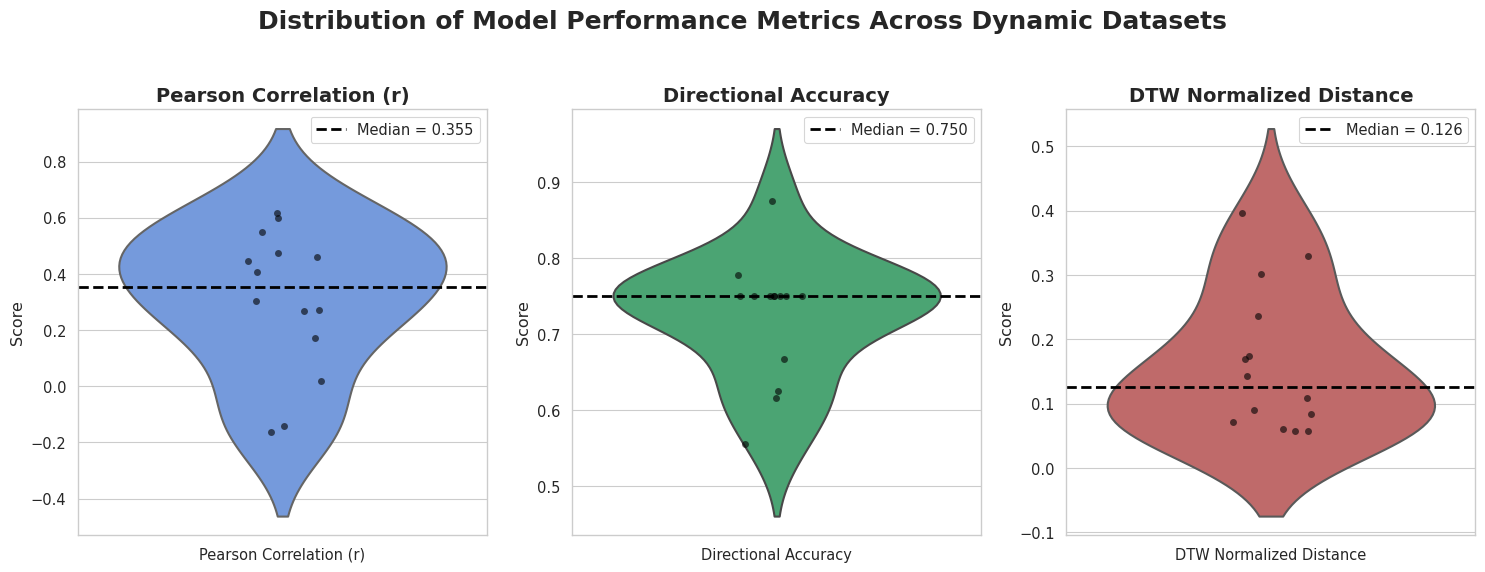

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:


def create_summary_plots(pearson_arr, dir_arr, dtw_arr):
    """
    Generates a professional, publication-quality summary plot for the
    Pearson, Directional Accuracy, and DTW results using seaborn.

    Args:
        pearson_arr (list): List of Pearson correlation coefficients.
        dir_arr (list): List of Directional Accuracy scores.
        dtw_arr (list): List of DTW distance scores.
    """
    # --- 1. Data Preparation and Cleaning ---
    # It's crucial for scientific integrity to only analyze the datasets
    # where dynamics were actually observed. We'll filter out the runs
    # where the metrics were zero (indicating no change).

    pearson_np = np.array(pearson_arr)
    dir_np = np.array(dir_arr)
    dtw_np = np.array(dtw_arr)

    # Create a mask to identify the "dynamic" datasets.
    # We'll consider a run non-dynamic if all metrics are very close to zero.
    dynamic_mask = (np.abs(pearson_np) > 0.001) | (np.abs(dir_np) > 0.001) | (np.abs(dtw_np) > 0.001)

    pearson_dynamic = pearson_np[dynamic_mask]
    dir_dynamic = dir_np[dynamic_mask]
    dtw_dynamic = dtw_np[dynamic_mask]

    print(f"Analysis based on {len(pearson_dynamic)} datasets with observed dynamics.")

    # --- 2. Create a Pandas DataFrame ---
    # Seaborn works best with "long-form" or "tidy" data. We create a DataFrame
    # with one column for the metric values and another for the metric type.

    data = pd.DataFrame({
        'Pearson Correlation (r)': pearson_dynamic,
        'Directional Accuracy': dir_dynamic,
        'DTW Normalized Distance': dtw_dynamic
    })

    # Melt the DataFrame to long-form
    data_melted = data.melt(var_name='Metric', value_name='Score')

    # --- 3. Plotting with Seaborn ---
    # Set a professional and aesthetically pleasing style
    sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)

    # Create the figure with 3 subplots (one for each metric)
    fig, axes = plt.subplots(1, 3, figsize=(15, 6), sharey=False) # Don't share Y-axis
    fig.suptitle('Distribution of Model Performance Metrics Across Dynamic Datasets', fontsize=18, fontweight='bold')

    # Define a color palette
    palette = {"Pearson Correlation (r)": "cornflowerblue",
               "Directional Accuracy": "mediumseagreen",
               "DTW Normalized Distance": "indianred"}

    metrics = ['Pearson Correlation (r)', 'Directional Accuracy', 'DTW Normalized Distance']

    for i, metric in enumerate(metrics):
        ax = axes[i]
        metric_data = data_melted[data_melted['Metric'] == metric]

        # Create a violin plot to show the distribution shape
        sns.violinplot(data=metric_data, x='Metric', y='Score', ax=ax,
                       color=palette[metric], inner=None, linewidth=1.5)

        # Overlay a stripplot to show individual data points
        sns.stripplot(data=metric_data, x='Metric', y='Score', ax=ax,
                      color='black', alpha=0.6, jitter=0.1)

        # Calculate and add the median as a horizontal line
        median_val = metric_data['Score'].median()
        ax.axhline(median_val, ls='--', color='black', lw=2,
                   label=f'Median = {median_val:.3f}')

        ax.set_xlabel('') # We don't need an x-label for a single category
        ax.set_ylabel('Score')
        ax.set_title(metric, fontsize=14, fontweight='bold')
        ax.legend(loc='best')

    # Improve layout and save the figure
    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust for suptitle

    # Save as SVG for high-quality, scalable vector graphic
    plt.savefig("model_performance_summary.svg", format="svg", dpi=300)

    plt.show()


if __name__ == '__main__':
    # --- Paste your collected data here ---
    pearson_arr = [0.5491534674665264, -0.16159108423075072, 0.47540716200012295, 0.3029443272201171, 0.4448684730805583, 0.2662269799651926, -0.1418189021989808, 0.4600878950001001, 0.6166349957646857, 0.2725882116124644, 0.17212130483803503, 0.5985421855354176, 0.018197193696413618, 0.4071179451448766, 0, 0, 0, 0, 0, 0, 0, 0, 0]
    dir_arr = [0.75, 0.6153846153846154, 0.6666666666666666, 0.5555555555555556, 0.7777777777777778, 0.75, 0.75, 0.75, 0.75, 0.75, 0.875, 0.75, 0.625, 0.75, 0, 0, 0, 0, 0, 0, 0, 0, 0]
    dtw_arr = [0.16991159409601192, 0.39548584768018674, 0.32940930273515395, 0.2366699631750525, 0.174755493703845, 0.08381729927498818, 0.10941354851742946, 0.0898223450454007, 0.05733542165990369, 0.057288176596609626, 0.14303036424717191, 0.06052890694559792, 0.30081189172488376, 0.0720720522547193, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]

    create_summary_plots(pearson_arr, dir_arr, dtw_arr)
    files.download("model_performance_summary.svg")

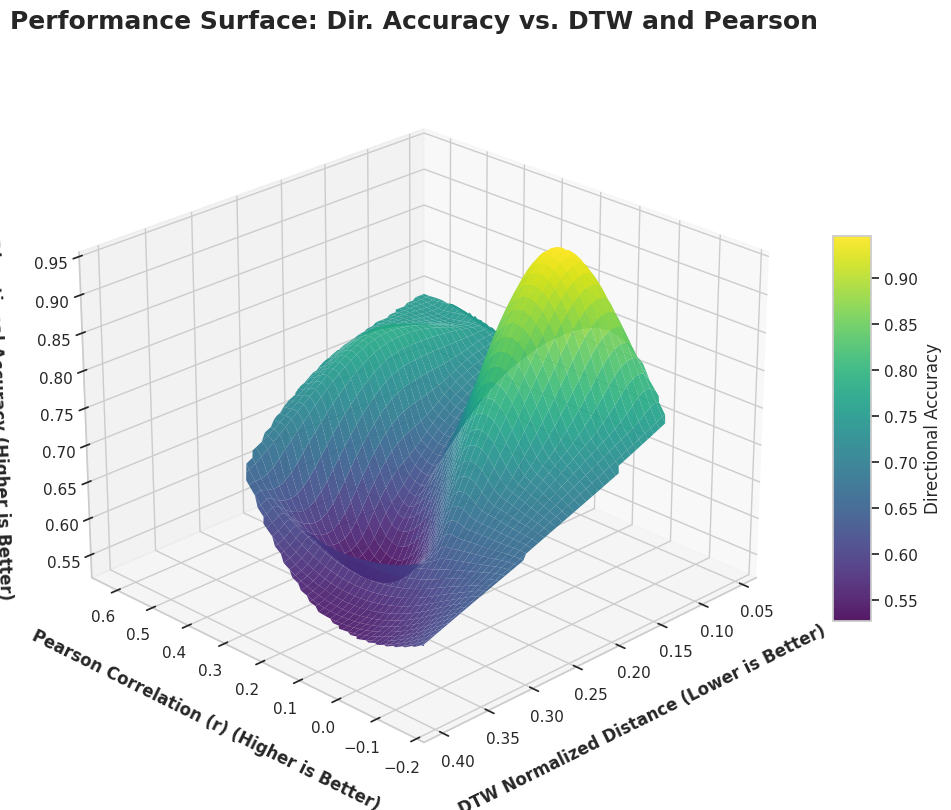

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:

from scipy.interpolate import griddata

def create_3d_surface_plot(pearson_arr, dir_arr, dtw_arr):
    """
    Generates a smoothed 3D surface plot showing the relationship
    between DTW, Pearson correlation, and Directional Accuracy.
    """
    # --- 1. Data Preparation and Cleaning (Same as before) ---
    pearson_np = np.array(pearson_arr)
    dir_np = np.array(dir_arr)
    dtw_np = np.array(dtw_arr)

    dynamic_mask = (np.abs(pearson_np) > 0.001) | (np.abs(dir_np) > 0.001) | (np.abs(dtw_np) > 0.001)

    x_data = dtw_np[dynamic_mask]       # DTW on X-axis
    y_data = pearson_np[dynamic_mask]   # Pearson on Y-axis
    z_data = dir_np[dynamic_mask]       # Directional Accuracy on Z-axis

    # --- 2. Interpolation for a Smooth Surface ---
    # Create a regular grid to interpolate onto
    xi = np.linspace(x_data.min(), x_data.max(), 100)
    yi = np.linspace(y_data.min(), y_data.max(), 100)
    X, Y = np.meshgrid(xi, yi)

    # Interpolate the Z values (Directional Accuracy) onto the grid
    # 'cubic' interpolation gives a nice smooth surface
    Z = griddata((x_data, y_data), z_data, (X, Y), method='cubic')

    # --- 3. 3D Plotting ---
    sns.set_theme(style="whitegrid")
    fig = plt.figure(figsize=(12, 10))
    ax = fig.add_subplot(111, projection='3d')

    # Plot the surface
    # 'viridis' is a perceptually uniform colormap, good for publications
    surf = ax.plot_surface(X, Y, Z, cmap='viridis', edgecolor='none', alpha=0.9)

    # --- Aesthetics and Labels ---
    ax.set_title('Performance Surface: Dir. Accuracy vs. DTW and Pearson', fontsize=18, fontweight='bold', pad=20)
    ax.set_xlabel('DTW Normalized Distance (Lower is Better)', fontsize=12, fontweight='bold', labelpad=15)
    ax.set_ylabel("Pearson Correlation (r) (Higher is Better)", fontsize=12, fontweight='bold', labelpad=15)
    ax.set_zlabel('Directional Accuracy (Higher is Better)', fontsize=12, fontweight='bold', labelpad=15)

    # Invert the DTW axis so the "good" corner is in the front
    ax.invert_xaxis()

    # Add a color bar to map colors to Directional Accuracy
    fig.colorbar(surf, shrink=0.5, aspect=10, label='Directional Accuracy')

    # Adjust viewing angle for a clear perspective
    ax.view_init(elev=25, azim=-135)

    plt.savefig("3d_performance_surface.svg", format="svg", dpi=300)
    plt.show()


if __name__ == '__main__':
    # --- Paste your collected data here ---
    pearson_arr = [0.5491534674665264, -0.16159108423075072, 0.47540716200012295, 0.3029443272201171, 0.4448684730805583, 0.2662269799651926, -0.1418189021989808, 0.4600878950001001, 0.6166349957646857, 0.2725882116124644, 0.17212130483803503, 0.5985421855354176, 0.018197193696413618, 0.4071179451448766, 0, 0, 0, 0, 0, 0, 0, 0, 0]
    dir_arr = [0.75, 0.6153846153846154, 0.6666666666666666, 0.5555555555555556, 0.7777777777777778, 0.75, 0.75, 0.75, 0.75, 0.75, 0.875, 0.75, 0.625, 0.75, 0, 0, 0, 0, 0, 0, 0, 0, 0]
    dtw_arr = [0.16991159409601192, 0.39548584768018674, 0.32940930273515395, 0.2366699631750525, 0.174755493703845, 0.08381729927498818, 0.10941354851742946, 0.0898223450454007, 0.05733542165990369, 0.057288176596609626, 0.14303036424717191, 0.06052890694559792, 0.30081189172488376, 0.0720720522547193, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]

    create_3d_surface_plot(pearson_arr, dir_arr, dtw_arr)

    files.download("3d_performance_surface.svg")

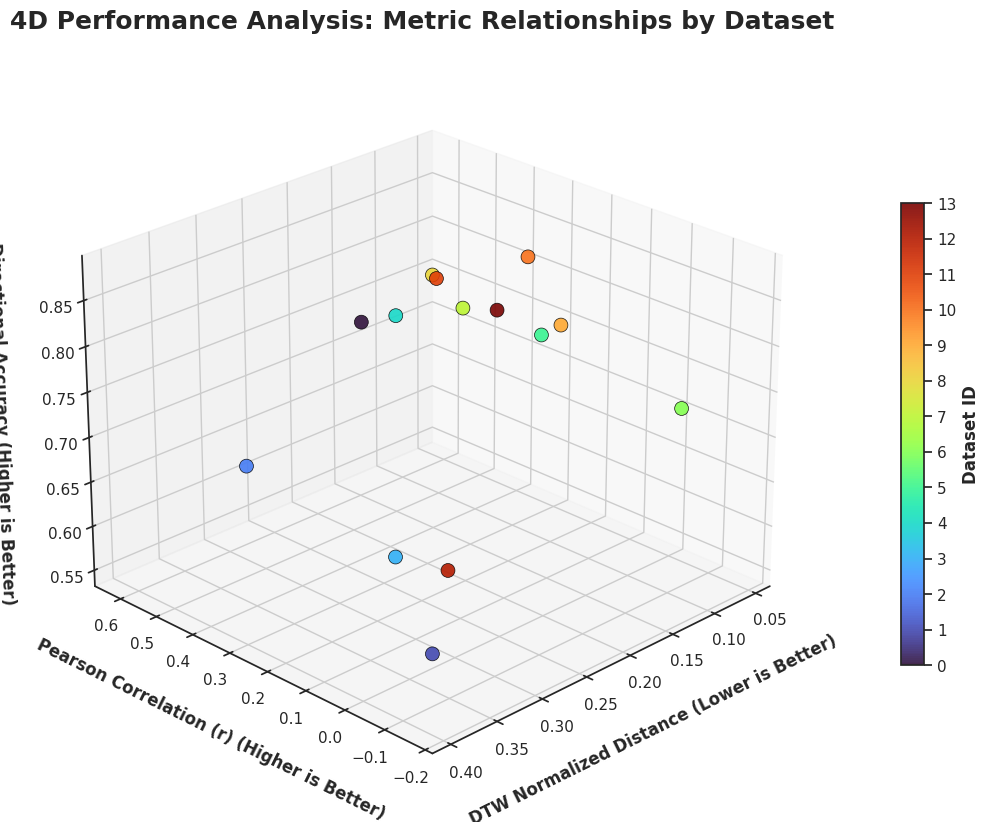

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def create_4d_performance_scatter(pearson_arr, dir_arr, dtw_arr):
    # --- 1. Data Preparation and Cleaning ---
    pearson_np = np.array(pearson_arr)
    dir_np = np.array(dir_arr)
    dtw_np = np.array(dtw_arr)

    # We need the original indices to use as our 4th dimension (color)
    indices = np.arange(len(pearson_np))

    # Filter for the dynamic datasets, but keep the original index
    dynamic_mask = (np.abs(pearson_np) > 0.001) | (np.abs(dir_np) > 0.001) | (np.abs(dtw_np) > 0.001)

    x_data = dtw_np[dynamic_mask]       # DTW on X-axis
    y_data = pearson_np[dynamic_mask]   # Pearson on Y-axis
    z_data = dir_np[dynamic_mask]       # Directional Accuracy on Z-axis

    # This is our 4th dimension
    color_data = indices[dynamic_mask]  # Dataset ID on Color-axis

    # --- 2. 3D Plotting with a 4th Dimension for Color ---
    sns.set_theme(style="white")
    fig = plt.figure(figsize=(13, 10))
    ax = fig.add_subplot(111, projection='3d')

    # The scatter plot
    # The 'c' argument is used for the color dimension.
    # We use a vibrant, categorical colormap like 'turbo' or 'tab20' to distinguish the datasets.
    scatter = ax.scatter(x_data, y_data, z_data,
                         c=color_data, cmap='turbo', s=100, alpha=0.9, edgecolors='black', linewidth=0.5)

    # --- Aesthetics and Labels ---
    ax.set_title('4D Performance Analysis: Metric Relationships by Dataset', fontsize=18, fontweight='bold', pad=20)
    ax.set_xlabel('DTW Normalized Distance (Lower is Better)', fontsize=12, fontweight='bold', labelpad=15)
    ax.set_ylabel("Pearson Correlation (r) (Higher is Better)", fontsize=12, fontweight='bold', labelpad=15)
    ax.set_zlabel('Directional Accuracy (Higher is Better)', fontsize=12, fontweight='bold', labelpad=15)

    # Invert the DTW axis so the "good" corner is in the front
    ax.invert_xaxis()

    # Add a color bar that shows which color corresponds to which dataset
    cbar = fig.colorbar(scatter, ax=ax, shrink=0.6, pad=0.1, ticks=np.unique(color_data))
    cbar.set_label('Dataset ID', fontsize=12, fontweight='bold')

    # Adjust viewing angle
    ax.view_init(elev=25, azim=-135)

    plt.savefig("4d_performance_scatter.svg", format="svg", dpi=300)
    plt.show()


if __name__ == '__main__':
    # --- Paste your collected data here ---
    pearson_arr = [0.549, -0.161, 0.475, 0.302, 0.444, 0.266, -0.141, 0.460, 0.616, 0.272, 0.172, 0.598, 0.018, 0.407, 0, 0, 0, 0, 0, 0, 0, 0, 0]
    dir_arr = [0.75, 0.615, 0.666, 0.555, 0.777, 0.75, 0.75, 0.75, 0.75, 0.75, 0.875, 0.75, 0.625, 0.75, 0, 0, 0, 0, 0, 0, 0, 0, 0]
    dtw_arr = [0.169, 0.395, 0.329, 0.236, 0.174, 0.083, 0.109, 0.089, 0.057, 0.057, 0.143, 0.060, 0.300, 0.072, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]

    create_4d_performance_scatter(pearson_arr, dir_arr, dtw_arr)

# OOS Sample Test

In [ ]:
print(avg_test_res)
print(warmstart_percent)
best_arr=[]
for i in range(0,250,50):
  best_arr.append(oos_tester(train_start,train_end,i,2))
print(best_arr)

"""
res_dict = {'avg_test_res': avg_test_res,
            'avg_sharpe_dict': avg_sharpe_dict,
            'oos_best_sharpe_arr': {'values': best_arr},
            'tracker_high': {'values':tracker_high[2]},
            'tracker_low': {'values':tracker_low[2]}}

# Convert the dictionary to a pandas DataFrame
result_df = pd.DataFrame.from_dict(res_dict, orient='index')

file_path = "warmabl_9_new_5.csv"

try:
    result_df.to_csv(file_path, index=True)
    print(f"Results dictionary saved to {file_path}")
    files.download(file_path)
    print(f"Downloaded {file_path}")
except Exception as e:
    print(f"An error occurred: {e}")
"""

{2: 43.511593058734064, 3: 43.621437789364656}
0.9
1000 1669
Backtest complete in 3.881 seconds

1000 1619
Backtest complete in 4.707 seconds

1000 1569


In [ ]:
normal_df = df[test_start:test_end].copy()
for i in range(1,32):
  base_alpha = normal_df[f"f{i}"]

  base_signal = np.where(base_alpha > signal_threshold, 1, np.where(base_alpha < -signal_threshold, -1, 0))

  # Instantiate the class with all required arguments
  signal_obj = SingleVectorBacktest(
      normal_df,
      base_signal)

  # Call the fitness function correctly on the created object
  sharpe = signal_obj.fitness(type="sharpe")
  ret=signal_obj.port_ret().total_profit()
  print(f"For Signal {i} the Sharpe Ratio: {sharpe:.2f} and returns are {ret:.4f}")

## Print Tree

In [ ]:

# Alternative implementation using a different approach
def print_tree_compact(root):
    """
    Prints a binary tree in a compact format without long spaces or underscores.
    Uses a more vertical representation with direct parent-child connections.
    """
    if not root:
        print("Empty tree")
        return

    def build_tree_string(node, prefix="", is_left=True):
        if node is None:
            return []

        result = []

        # Process right child first (will appear at the top)
        if node.right:
            extension = "│   " if is_left else "    "
            result.extend(build_tree_string(node.right, prefix + extension, False))

        # Add current node
        line = prefix + ("└── " if is_left else "┌── ") + str(node.val)
        result.append(line)

        # Process left child
        if node.left:
            extension = "    " if is_left else "│   "
            result.extend(build_tree_string(node.left, prefix + extension, True))

        return result

    # Print the tree lines
    tree_lines = build_tree_string(root, "", True)
    for line in tree_lines:
        print(line)

In [ ]:
print_tree_compact(dict_low[2]["tree_opt"][10])

│           ┌── 15
│       ┌── 3
│       │   └── 3
│   ┌── 2
│   │   │   ┌── 22
│   │   └── 3
│   │       └── 15
└── 1
    │           ┌── 18
    │       ┌── 2
    │       │   └── 15
    │   ┌── 2
    │   │   └── 2
    └── 1
        │           ┌── 12
        │       ┌── 0
        │       │   └── 8
        │   ┌── 2
        │   │   │   ┌── 18
        │   │   └── 3
        │   │       │   ┌── 12
        │   │       └── 0
        │   │           └── 8
        └── 2
            │       ┌── 12
            │   ┌── 0
            │   │   └── 3
            └── 1
                │       ┌── 22
                │   ┌── 2
                │   │   └── 15
                └── 3
                    └── 14


In [ ]:
print(f"For high vol tree")
for i in range(98):
  print_tree_compact(dict_low[3]["tree_opt"][i])
  print("##########################430AN `#######################")

# Ablations

## Ablations:
- Removing the effect of Simulated Annealing:
  - Don't suppress the fitness.Keep it as it is.
  - Metric:
    - Check how the avg.fitness changes over the entire time period.(keep in mind that when involving simulated annealing and fitness calculation we need to take into account the original fitness not the suppressed one because even though we suppress it that is for algorithmic purpose rather than metric purpose.)
- Removing the effect of subsequent warmstarts after each datasets:
  - Only do warmstart for the 1st dataset.
- Try out with different fitness functions and compare the results
- Removing the adaptive mechanism:
  - Try out with different constant rates
  - Also make charts comparing the rates for different depths across different generations.
- Distributive mechanism:
  - Try out different window sizes and how does the result compare. This is what we need to do.
- Try only strategy generated in each regime separately with the ones done by using meta signal.



**RANSAC and Regression plots for Ablation**

In [ ]:
print(tracker_low[2])

[150, 84, 55, 33, 21, 13, 10, 7, 6, 5, 3, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2]


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def analyze_warmstart_ablation(experimental_survivors, prob_bound=0.25, min_pop_thresh=0.05):
    """
    Analyzes the warmstart ablation study results against the theoretical model,
    starting the analysis from step D=0.

    Args:
        experimental_survivors (list): The measured number of survivors at each step,
                                     INCLUDING the initial count at step 0.
        k (float): The warmstart_percent value (e.g., 0.9).
        num_individuals (int): Total population size (N).
        prob_bound (float): The Azuma-Hoeffding probability bound.
        min_pop_thresh (float): The threshold for when to stop counting.
    """
    # The number of steps D is one less than the length of the data array
    num_steps = len(experimental_survivors) - 1

    # --- 1. Calculate Theoretical Expected Survivors (μ_D) ---
    # Probabilities for steps 1, 2, ..., D
    k=warmstart_percent
    step_probs = 1 / (1 + k**np.arange(1, num_steps + 1))
    # Prepend 1.0 for the survival probability at step 0
    survival_probs = np.insert(step_probs, 0, 1.0)

    # The cumulative product now correctly calculates the full sequence μ_0, μ_1, ...
    mu_arr = num_individuals * np.cumprod(survival_probs)

    # --- 2. Correctly Calculate Azuma-Hoeffding Confidence Interval ---
    conf_intervals = []
    # Add the interval for D=0: no uncertainty, so the interval is just [N, N]
    conf_intervals.append((num_individuals, num_individuals))

    # Calculate intervals for steps 1 through D
    for D_current in range(1, num_steps + 1):
        # c_i = product of survival probabilities from i+1 to D_current
        c_i_sq_sum = 0
        for i in range(1, D_current + 1):
            # The survival_probs array is 0-indexed and includes the initial '1'.
            # So the probability for step j is at index j.
            # We need the product from index i+1 to D_current+1.
            c_i = np.prod(survival_probs[i+1 : D_current+1])
            c_i_sq_sum += c_i**2

        az_denominator = 2 * c_i_sq_sum

        t = 0
        found_bound = False
        while t < num_individuals:
            if az_denominator > 1e-10: # Avoid division by zero
                prob = 2 * np.exp(-(t**2 / az_denominator))
                if prob <= prob_bound:
                    conf_intervals.append((max(0, mu_arr[D_current] - t), mu_arr[D_current] + t))
                    found_bound = True
                    break
            t += 1
        if not found_bound:
            conf_intervals.append((mu_arr[D_current], mu_arr[D_current]))

    # --- 3. Compare Experimental Data to Confidence Intervals ---
    fail_count = 0
    total_count = 0
    for i in range(num_steps + 1):
        if mu_arr[i] > (min_pop_thresh * num_individuals):
            continue

        total_count += 1
        lower_bound, upper_bound = conf_intervals[i]

        if not (lower_bound <= experimental_survivors[i] <= upper_bound):
            fail_count += 1

    print(f"--- Results for k = {k} ---")
    if total_count > 0:
        print(f"Model failed to capture experiment in {fail_count}/{total_count} instances ({fail_count/total_count:.1%}).")
    else:
        print("No instances met the population threshold for analysis.")
    print("****************************")

In [ ]:
analyze_warmstart_ablation(tracker_high[2],0.05,0.1)
analyze_warmstart_ablation(tracker_high[3],0.05,0.1)
analyze_warmstart_ablation(tracker_low[2],0.05,0.1)
analyze_warmstart_ablation(tracker_low[3],0.05,0.1)

--- Results for k = 0.9 ---
Model failed to capture experiment in 0/18 instances (0.0%).
****************************
--- Results for k = 0.9 ---
Model failed to capture experiment in 1/18 instances (5.6%).
****************************
--- Results for k = 0.9 ---
Model failed to capture experiment in 0/18 instances (0.0%).
****************************
--- Results for k = 0.9 ---
Model failed to capture experiment in 0/18 instances (0.0%).
****************************


In [ ]:
from operator import le
k9=[11,4,7,3,9,4,7,1,2,5,1,4,4,5,2,6,4,5,1,4,9,3,8,4,2,2,1,1,9,4,2,4,8,2,3,3,3,3,6,2]

k8=[23,6,8,4,9,9,5,4,18,3,7,3,23,10,7,4,7,5,6,4,6,5,2,3,4,21,8,4,10,4,2,4,5,4,3,3,4,23,2,2]
sp8=np.array([1.21+1.18+0.91+0.43+0.82,1.54+1.72+1.54+0.99+1.06,1.11+1.72+1.54+0.33+0.82,1.02+0.96+1.54+0.32+0.96,1.64+2.16+1.7+0.94+1.5,1.58+2+1.56+1.77+1.54,1.15+1.23+1.54+0.33+0.83,1.2+1.33+1.15+0.9+1.03,1.12+1.32+1.45+0.51+0.82,1.34+1.40+1.49+0.39+0.82])
sp9=np.array([1.2+1.14+1.76+1.32+1.51,0.47+1.47+1.63+0.78+1.35,1.36+2.05+1.86+1.58+1.8,1.28+1.2+1.88+1.64+1.77,0.76+1.52+1.50+1.13+1.42,1.96+1.94+2.16+2.11+2.14,1.47+2.38+2.12+0.58+1.3,1.21+1.25+1.54+0.7+1.03,0.9+1.44+1.89+1.42+1.48,1.16+2.03+1.64+1.52+1.4])
print(len(sp9))
print(len(k9))
print(np.mean(sp9/5))
print(len(sp8))
print(len(k8))
print(np.mean(sp8/5))

10
40
1.483
10
40
1.1892


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import RANSACRegressor, LinearRegression

def regRANSAC_plot(y, avg_batch_size):
    #y_avg=np.array(y).reshape(-1, avg_batch_size).mean(axis=1)
    x=np.array([np.float64(i) for i in range(len(y))])
    #x_avg=np.array([np.float64(i*avg_batch_size) for i in range(len(y_avg))])

    # Create scatter plot (data points)
    plt.scatter(x, y, color='red', label='Data Points')

    # Create scatter plot (avg points)
    #plt.scatter(x_avg, y_avg, color='red', label='Avg Points')

    # Plot Linear Regression
    a,b = np.polyfit(x, y, 1)
    plt.plot(x, a*x + b, color='blue', label=f'Regression: y = {a:.4f}x+ {b:.4f}')

    # Plot Linear Regression (Avg window)
    #a,b = np.polyfit(x_avg, y_avg, 1)
    #plt.plot(x, a*x + b, color='red', label=f'Regression(avg window): y = {a:.4f}x+ {b:.4f}')

    # RANSAC model
    ransac = RANSACRegressor(#base_estimator=LinearRegression(),
                             min_samples=2,
                             #residual_threshold=0.5,
                             max_trials=1000,
                             random_state=42)
    x1 = x.reshape(-1, 1)
    ransac.fit(x1, y)
    slope = ransac.estimator_.coef_[0]
    intercept = ransac.predict([[0]])[0]

    # Plot RANSAC line
    plt.plot(x, slope*x + intercept, color='green', label=f'RANSAC: y = {slope:.4f}x+ {intercept:.4f}')

    # Add labels and legend
    plt.xlabel('x')
    plt.ylabel('y')
    plt.title('Fit')
    plt.legend()
    plt.show()

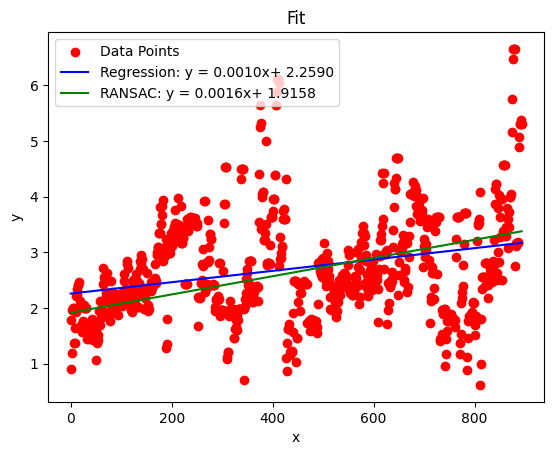

In [ ]:
y=simulated_avg_fitness_train_high[3]
regRANSAC_plot(y,avg_batch_size=3)

# Ablation for rate


- 1. Establish the Baseline
  - Run your script multiple times (e.g., 10 runs, ideally with different SEED values).
  - Collect Metrics for Each Run: Primary Performance Metrics (Test Set):
  - The average Sharpe ratio for each depth across all sliding windows (from avg_test_res and avg_sharpe_dict).
  - The maximum profit achieved for each depth across all sliding windows.
  - Distribution of Sharpe ratios (e.g., median, quartiles, standard deviation) from test sets.
  - Training Dynamics:Average elite fitness over generations for high and low volatility regimes(simulated_avg_fitness_train_high, simulated_avg_fitness_train_low).
  - Adaptive Rate Behavior:Log the values of kwargs["curr_cross_rate"] and kwargs["curr_mut_rate"] at each generation.This will show how the rates are adapting.
-  Define and Implement the Ablated Condition (Fixed Rates):
    - Modify your script: Set is_fixed_rate = True.Choose Fixed Rate Values with these options for fixed_cross_rate and fixed_mut_rate:
      - Option A (Script Defaults): Use the current default fixed rates: fixed_cross_rate = 0.65 and fixed_mut_rate=0.2
     - Option B: -e.g., low/low, high/high, high_cross/low_mut, low_cross/high_mut. (Average Observed Adaptive Rates): After running the baseline (adaptive) version, calculate the average crossover and mutation rates that the adaptive mechanism converged to or hovered around. Use these averages as your fixed rates. This can provide a very fair comparison.

 - Ensure all other hyperparameters remain identical to the baseline runs.Run the script with fixed rates multiple times, similar to the baseline.Collect the Same Metrics as in step 1 (except for adaptive rate behavior, as rates will be constant).
- 3. Analyze and Compare Results:
  - For each primary performance metric (e.g., average test Sharpe ratio for depth 3), compare the average and distribution (e.g., using box plots) from the adaptive runs versus the fixed-rate runs.
  - Use statistical tests (e.g., t-test or Mann-Whitney U test, depending on data distribution) to determine if the differences in performance are statistically significant.
  - Compare the convergence speed from the training dynamics plots. Does the adaptive version find good solutions faster? Does it reach higher fitness levels?

- Visualization:
  - Plot average test Sharpe ratios (and other key metrics) with error bars (representing standard deviation or confidence intervals) for adaptive vs. fixed-rate versions.
  - Overlay training fitness curves.Plot the evolution of adaptive rates themselves from the baseline runs.

## Analysis hints
- Use regRANSAC for analysis:
  - avg_test_res,simulated_avg_fitness_train_high,simulated_avg_fitness_train_low needs to be analysed here
  - below are codes for t-test and MannWhitley-test which we need to test for different studies.
  - IMPORTANT-run it for atleast 15 times to get a better understanding of the distribution

In [ ]:
from scipy import stats

# Replace with your actual fitness data
#type 1 array:simulated_avg_fitness_train_high,simulated_avg_fitness_train_low
fitness_group_a = np.array([0.5, 0.6, 0.55, 0.62, 0.58, 0.7, 0.59, 0.63, 0.65, 0.57])#array for adaptive
fitness_group_b = np.array([0.7, 0.72, 0.68, 0.75, 0.71, 0.8, 0.73, 0.76, 0.78, 0.69])#array for experiment

# Perform independent samples t-test
t_statistic, p_value = stats.ttest_ind(fitness_group_a, fitness_group_b)

print(f"T-statistic: {t_statistic}")
print(f"P-value: {p_value}")

# Interpret the results
alpha = 0.05  # Significance level
if p_value < alpha:
    print("The difference in means is statistically significant.")
else:
    print("The difference in means is not statistically significant.")

In [ ]:
from scipy import stats
import numpy as np


# Perform Mann-Whitney U test
statistic, p_value = stats.mannwhitneyu(fitness_group_a, fitness_group_b)

print(f"Mann-Whitney U statistic: {statistic}")
print(f"P-value: {p_value}")

# Interpret the results
alpha = 0.05  # Significance level
if p_value < alpha:
    print("The difference in distributions is statistically significant.")
else:
    print("The difference in distributions is not statistically significant.")

In [ ]:
from google.colab import files
f=files.upload()

In [ ]:
import pandas as pd
import ast
import numpy as np

In [ ]:
def parse_numpy_float_string(s):
    """
    Manually parses a string that might contain np.float64(...)
    """
    s = s.replace('np.float64(', '').replace(')', '')
    try:
        # Safely evaluate the cleaned string
        return ast.literal_eval(s)
    except (ValueError, SyntaxError) as e:
        print(f"Error parsing string after cleaning: {e}")
        return {}
def process_df(df_path):
  df_c=pd.read_csv(df_path)
  df_c = df_c.rename(columns={'Unnamed: 0': 'Metric'})
  restored_dict1,restored_dict2= parse_numpy_float_string(df_c['2'][2]),parse_numpy_float_string(df_c['2'][3])
  return restored_dict1,restored_dict2

In [ ]:
def oos_process_df(df_path):
  df_c=pd.read_csv(df_path)
  df_c = df_c.rename(columns={'Unnamed: 0': 'Metric'})
  restored_dict= parse_numpy_float_string(df_c['values'][4])
  return restored_dict

In [ ]:
oos_dict=[]
for i in range(1,21):
  oos_restored_dict=oos_process_df(f"/content/sim_results{i}.csv")
  oos_dict.append(oos_restored_dict)

[[-0.5312042760942384, -0.2530775058217786, -1.205966359953658, 0.32695610122823676, 0.6686872784344823], [0.30071212700073624, 0.7945759680412943, 0.17880718616224134, 0.32695610122823676, 0.8209631224798222], [0.47120809130481395, 0.9434504221065999, 0.8537467854967281, 0.32695610122823676, 0.817616672182881], [0.5620747143957969, 1.323136268992513, 0.8537467854967281, 0.32695610122823676, 0.817616672182881], [0.30071212700073624, -0.054782679470089704, 0.5495081927261033, 0.02410686514386476, 0.3967814001964023], [0.667088217977334, 0.9973671283735225, 1.3012496985840614, 0.7373454302617659, 1.0413437268542998], [-0.32412049485378913, -0.023947565106529383, -0.6904735907981041, -0.19768659774634909, -1.036143279386003], [0.20326578294640352, 0.7348909221704742, 0.5561806041325468, -0.19768659774634909, -0.4856593122711212], [0.9296802301689951, 1.471220614556522, 0.8537467854967281, 0.32695610122823676, 0.9594893095902117], [0.6080248077679679, 1.3629183737685606, 0.2803385901270545

In [ ]:
arr_dict,arr_dict1=[],[]
min_range,min_range1=[150]*23,[150]*23
for i in range(1,21):
  restored_dict1,restored_dict2=process_df(f"/content/sim_results{i}.csv")
  arr_dict.append(restored_dict1)
  arr_dict1.append(restored_dict2)
  for j in range(23):
    if(min_range[j]>len(restored_dict1[j])):
      min_range[j]=len(restored_dict1[j])
    if(min_range1[j]>len(restored_dict2[j])):
      min_range1[j]=len(restored_dict2[j])

In [ ]:
print(min_range)
print(min_range1)

[27, 14, 14, 18, 21, 21, 21, 18, 28, 28, 20, 19, 13, 16, 21, 19, 33, 20, 28, 22, 47, 40, 21]
[27, 14, 14, 18, 21, 21, 21, 18, 28, 28, 20, 19, 13, 16, 21, 19, 33, 20, 28, 22, 47, 40, 21]


In [ ]:
print(len(arr_dict))

20


In [ ]:
avg_exp_del,avg_price_del={},{}
for i in range(23):
  exp_arr,price_arr=[],[]
  for g in range(min_range[i]):
    exp_arr.append(np.mean([arr_dict[j][i][g] for j in range(20)]))
    price_arr.append(np.mean([arr_dict1[j][i][g] for j in range(20)]))
  avg_exp_del[i]=exp_arr
  avg_price_del[i]=price_arr

In [ ]:
from scipy.stats import pearsonr
!pip install dtw-python
from dtw import dtw

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D

In [ ]:
pearson_arr,dir_arr,dtw_arr=[],[],[]
def analyze_dynamics(dp):
    """
    Performs a sophisticated analysis and plots the results.
    """
    # --- Data Preparation ---
    exp_d = np.array(avg_exp_del[dp])
    experimental_deltas = exp_d[1:] - exp_d[:-1]
    # Assuming scaling is needed for viz, apply after potentially getting rid of NaNs/Infs
    theoretical_deltas = np.array(avg_price_del[dp])

    y_true_smoothed = pd.Series(experimental_deltas).rolling(window=2, min_periods=1, center=True).mean().to_numpy()
    y_pred = theoretical_deltas

    # Ensure both arrays have the same length by taking the minimum length
    min_len = min(len(y_true_smoothed), len(y_pred))
    y_true_smoothed = y_true_smoothed[:min_len]
    y_pred = y_pred[:min_len]


    # --- Phase-Specific Analysis ---
    dynamic_phase_mask = np.abs(y_true_smoothed) > 0.01
    # Combine with finite check
    finite_mask = np.isfinite(y_true_smoothed) & np.isfinite(y_pred)
    combined_mask = dynamic_phase_mask & finite_mask

    y_true_dynamic = y_true_smoothed[combined_mask]
    y_pred_dynamic = y_pred[combined_mask]

    # Calculate metrics ONLY on the dynamic phase
    pearson_corr, _ = pearsonr(y_pred_dynamic, y_true_dynamic) if len(y_true_dynamic) > 1 else (0, 0)

    # Calculate Directional Accuracy
    same_direction = np.sign(y_pred_dynamic) == np.sign(y_true_dynamic)
    dir_accuracy = np.mean(same_direction) if len(y_true_dynamic) > 0 else 0

    full_mask = np.isfinite(y_true_smoothed) & np.isfinite(y_pred)
    y_true_filtered_full = y_true_smoothed[full_mask]
    y_pred_filtered_full = y_pred[full_mask]

    if len(y_true_filtered_full) > 0 and len(y_pred_filtered_full) > 0:
        dtw_result = dtw(y_pred_filtered_full, y_true_filtered_full, keep_internals=True)
        dtw_distance = dtw_result.normalizedDistance
    else:
        dtw_distance = np.nan # Or some other indicator for no data

    return pearson_corr,dir_accuracy,dtw_distance


for i in range(23):
  # Call the function and unpack the results
  pear, dir, dtw_val = analyze_dynamics(i)
  pearson_arr.append(pear)
  dir_arr.append(dir)
  # Append the dtw_val obtained from the function call
  dtw_arr.append(dtw_val)

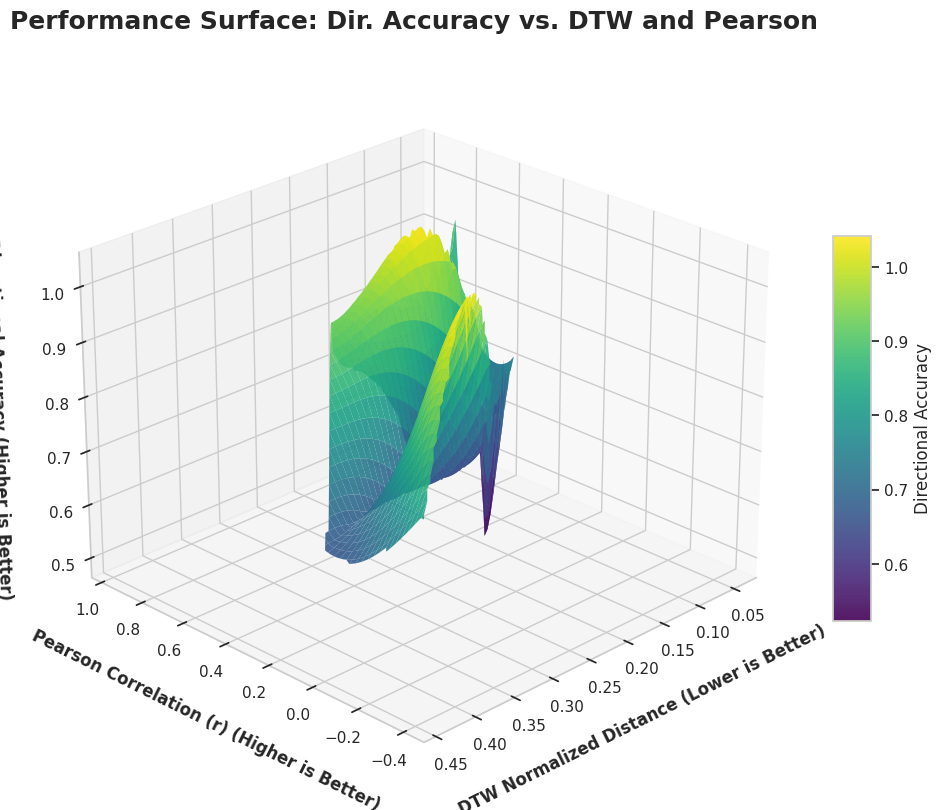

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:

from scipy.interpolate import griddata

def create_3d_surface_plot(pearson_arr, dir_arr, dtw_arr):
    """
    Generates a smoothed 3D surface plot showing the relationship
    between DTW, Pearson correlation, and Directional Accuracy.
    """
    # --- 1. Data Preparation and Cleaning (Same as before) ---
    pearson_np = np.array(pearson_arr)
    dir_np = np.array(dir_arr)
    dtw_np = np.array(dtw_arr)

    dynamic_mask = (np.abs(pearson_np) > 0.001) | (np.abs(dir_np) > 0.001) | (np.abs(dtw_np) > 0.001)

    x_data = dtw_np[dynamic_mask]       # DTW on X-axis
    y_data = pearson_np[dynamic_mask]   # Pearson on Y-axis
    z_data = dir_np[dynamic_mask]       # Directional Accuracy on Z-axis

    # --- 2. Interpolation for a Smooth Surface ---
    # Create a regular grid to interpolate onto
    xi = np.linspace(x_data.min(), x_data.max(), 100)
    yi = np.linspace(y_data.min(), y_data.max(), 100)
    X, Y = np.meshgrid(xi, yi)

    # Interpolate the Z values (Directional Accuracy) onto the grid
    # 'cubic' interpolation gives a nice smooth surface
    Z = griddata((x_data, y_data), z_data, (X, Y), method='cubic')

    # --- 3. 3D Plotting ---
    sns.set_theme(style="whitegrid")
    fig = plt.figure(figsize=(12, 10))
    ax = fig.add_subplot(111, projection='3d')

    # Plot the surface
    # 'viridis' is a perceptually uniform colormap, good for publications
    surf = ax.plot_surface(X, Y, Z, cmap='viridis', edgecolor='none', alpha=0.9)

    # --- Aesthetics and Labels ---
    ax.set_title('Performance Surface: Dir. Accuracy vs. DTW and Pearson', fontsize=18, fontweight='bold', pad=20)
    ax.set_xlabel('DTW Normalized Distance (Lower is Better)', fontsize=12, fontweight='bold', labelpad=15)
    ax.set_ylabel("Pearson Correlation (r) (Higher is Better)", fontsize=12, fontweight='bold', labelpad=15)
    ax.set_zlabel('Directional Accuracy (Higher is Better)', fontsize=12, fontweight='bold', labelpad=15)

    # Invert the DTW axis so the "good" corner is in the front
    ax.invert_xaxis()

    # Add a color bar to map colors to Directional Accuracy
    fig.colorbar(surf, shrink=0.5, aspect=10, label='Directional Accuracy')

    # Adjust viewing angle for a clear perspective
    ax.view_init(elev=25, azim=-135)

    plt.savefig("3d_performance_surface_avg.svg", format="svg", dpi=300)
    plt.show()


if __name__ == '__main__':
    # --- Paste your collected data here ---
    create_3d_surface_plot(pearson_arr, dir_arr, dtw_arr)

    files.download("3d_performance_surface_avg.svg")

Analysis based on 23 datasets with observed dynamics.


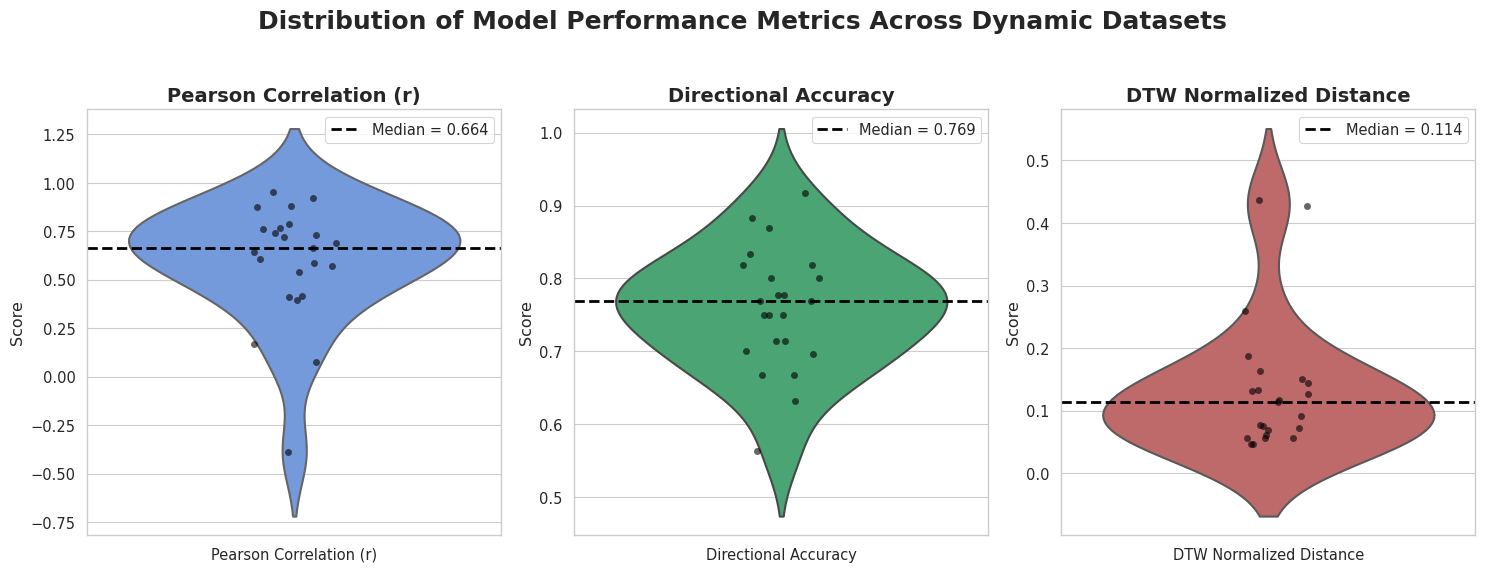

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:


def create_summary_plots(pearson_arr, dir_arr, dtw_arr):
    """
    Generates a professional, publication-quality summary plot for the
    Pearson, Directional Accuracy, and DTW results using seaborn.

    Args:
        pearson_arr (list): List of Pearson correlation coefficients.
        dir_arr (list): List of Directional Accuracy scores.
        dtw_arr (list): List of DTW distance scores.
    """
    # --- 1. Data Preparation and Cleaning ---
    # It's crucial for scientific integrity to only analyze the datasets
    # where dynamics were actually observed. We'll filter out the runs
    # where the metrics were zero (indicating no change).

    pearson_np = np.array(pearson_arr)
    dir_np = np.array(dir_arr)
    dtw_np = np.array(dtw_arr)

    # Create a mask to identify the "dynamic" datasets.
    # We'll consider a run non-dynamic if all metrics are very close to zero.
    dynamic_mask = (np.abs(pearson_np) > 0.001) | (np.abs(dir_np) > 0.001) | (np.abs(dtw_np) > 0.001)

    pearson_dynamic = pearson_np[dynamic_mask]
    dir_dynamic = dir_np[dynamic_mask]
    dtw_dynamic = dtw_np[dynamic_mask]

    print(f"Analysis based on {len(pearson_dynamic)} datasets with observed dynamics.")

    # --- 2. Create a Pandas DataFrame ---
    # Seaborn works best with "long-form" or "tidy" data. We create a DataFrame
    # with one column for the metric values and another for the metric type.

    data = pd.DataFrame({
        'Pearson Correlation (r)': pearson_dynamic,
        'Directional Accuracy': dir_dynamic,
        'DTW Normalized Distance': dtw_dynamic
    })

    # Melt the DataFrame to long-form
    data_melted = data.melt(var_name='Metric', value_name='Score')

    # --- 3. Plotting with Seaborn ---
    # Set a professional and aesthetically pleasing style
    sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)

    # Create the figure with 3 subplots (one for each metric)
    fig, axes = plt.subplots(1, 3, figsize=(15, 6), sharey=False) # Don't share Y-axis
    fig.suptitle('Distribution of Model Performance Metrics Across Dynamic Datasets', fontsize=18, fontweight='bold')

    # Define a color palette
    palette = {"Pearson Correlation (r)": "cornflowerblue",
               "Directional Accuracy": "mediumseagreen",
               "DTW Normalized Distance": "indianred"}

    metrics = ['Pearson Correlation (r)', 'Directional Accuracy', 'DTW Normalized Distance']

    for i, metric in enumerate(metrics):
        ax = axes[i]
        metric_data = data_melted[data_melted['Metric'] == metric]

        # Create a violin plot to show the distribution shape
        sns.violinplot(data=metric_data, x='Metric', y='Score', ax=ax,
                       color=palette[metric], inner=None, linewidth=1.5)

        # Overlay a stripplot to show individual data points
        sns.stripplot(data=metric_data, x='Metric', y='Score', ax=ax,
                      color='black', alpha=0.6, jitter=0.1)

        # Calculate and add the median as a horizontal line
        median_val = metric_data['Score'].median()
        ax.axhline(median_val, ls='--', color='black', lw=2,
                   label=f'Median = {median_val:.3f}')

        ax.set_xlabel('') # We don't need an x-label for a single category
        ax.set_ylabel('Score')
        ax.set_title(metric, fontsize=14, fontweight='bold')
        ax.legend(loc='best')

    # Improve layout and save the figure
    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust for suptitle

    # Save as SVG for high-quality, scalable vector graphic
    plt.savefig("model_performance_summary_avg.svg", format="svg", dpi=300)

    plt.show()


if __name__ == '__main__':
    # --- Paste your collected data here ---
    create_summary_plots(pearson_arr, dir_arr, dtw_arr)
    files.download("model_performance_summary_avg.svg")

[0.32035967 0.52278347 0.33491073 0.18705592 0.4660014 ]


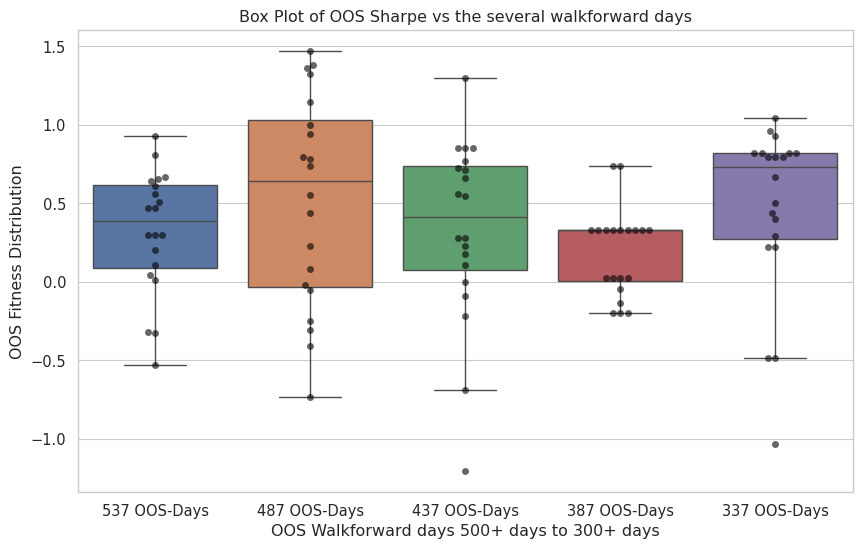

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<Figure size 640x480 with 0 Axes>

In [ ]:
import seaborn as sns

data = np.array(oos_dict)

#mean along the rows
mean_array = np.mean(data, axis=0)
print(mean_array)

df_data = pd.DataFrame(data, columns=[f'{int(537-i*50)} OOS-Days' for i in range(data.shape[1])])

# Create the box plot
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_data, showfliers=False)
sns.swarmplot(data=df_data, color='black', size=5, alpha=0.6)

#plt.plot(np.arange(data.shape[1]), mean_array, 'ro', markersize=8, label='Mean')

plt.title('Box Plot of OOS Sharpe vs the several walkforward days')
plt.ylabel('OOS Fitness Distribution')
plt.xlabel('OOS Walkforward days 500+ days to 300+ days')
#plt.legend() # Removed legend call as there are no labeled artists currently
plt.show() # Show the plot first

# Save the figure as an SVG file
plt.savefig("oos_boxplot.svg", format="svg")

# Download the saved file
files.download("oos_boxplot.svg")